In [1]:
# ============================================================
# AMAZON INDIA - 1500 PRODUCT SCRAPER + CLEANING PIPELINE
# 500 Laptops + 500 Mobiles + 500 Washing Machines
# ============================================================

import re
import time
import shutil
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.edge.service import Service as EdgeService
from selenium.webdriver.edge.options import Options as EdgeOptions


# ============================================================
# CONFIGURATION
# ============================================================

TARGET_PER_CATEGORY = 500
TOTAL_TARGET = TARGET_PER_CATEGORY * 3

CHECKPOINT_FILE = "amazon_1500_checkpoint.csv"
RAW_FILE = "amazon_1500_products_raw.csv"
CLEAN_FILE = "amazon_1500_products_cleaned.csv"

MAX_PAGES_PER_QUERY = 10
PAGE_DELAY = 2.5


# ============================================================
# SEARCH QUERIES
# ============================================================

SEARCH_QUERIES = {

    "laptops": [
        "laptop",
        "gaming laptop",
        "business laptop",
        "student laptop",
        "thin light laptop",
        "Lenovo laptop",
        "HP laptop",
        "Dell laptop",
        "ASUS laptop",
        "Acer laptop",
        "Apple MacBook",
        "Core i5 laptop",
        "Core i7 laptop",
        "Ryzen 5 laptop",
        "Ryzen 7 laptop",
        "16GB laptop",
        "8GB laptop",
        "512GB SSD laptop",
        "1TB laptop",
        "14 inch laptop"
    ],

    "mobiles": [
        "mobile phone",
        "smartphone",
        "5G mobile",
        "Android phone",
        "Samsung phone",
        "OnePlus phone",
        "Redmi phone",
        "Vivo phone",
        "Oppo phone",
        "Realme phone",
        "Motorola phone",
        "iQOO phone",
        "Poco phone",
        "Nothing phone",
        "8GB RAM phone",
        "12GB RAM phone",
        "256GB phone",
        "128GB phone",
        "5000mAh phone",
        "AMOLED phone"
    ],

    "washing_machines": [
        "washing machine",
        "front load washing machine",
        "top load washing machine",
        "fully automatic washing machine",
        "semi automatic washing machine",
        "LG washing machine",
        "Samsung washing machine",
        "Whirlpool washing machine",
        "IFB washing machine",
        "Bosch washing machine",
        "Panasonic washing machine",
        "Haier washing machine",
        "7 kg washing machine",
        "8 kg washing machine",
        "9 kg washing machine",
        "6 kg washing machine",
        "5 star washing machine",
        "inverter washing machine",
        "fully automatic top load",
        "fully automatic front load"
    ]
}


# ============================================================
# BASIC TEXT CLEANING
# ============================================================

def clean_text(value):

    if value is None:
        return None

    value = re.sub(r"\s+", " ", str(value)).strip()

    return value if value else None


def first_number(text):

    if not text:
        return None

    text = str(text).replace(",", "")

    match = re.search(
        r"(\d+(?:\.\d+)?)",
        text
    )

    return match.group(1) if match else None


# ============================================================
# PRICE EXTRACTION
# ============================================================

def extract_price(item):

    selectors = [
        "span.a-price span.a-offscreen",
        "span.a-price-whole"
    ]

    for selector in selectors:

        tag = item.select_one(selector)

        if tag:

            number = first_number(
                tag.get_text(" ", strip=True)
            )

            if number:
                return float(number)

    return None


# ============================================================
# MRP EXTRACTION
# ============================================================

def extract_mrp(item):

    selectors = [
        "span.a-price.a-text-price span.a-offscreen",
        "span.a-price.a-text-price",
        "span.a-text-price span.a-offscreen"
    ]

    price = extract_price(item)

    for selector in selectors:

        tags = item.select(selector)

        for tag in tags:

            text = tag.get_text(
                " ",
                strip=True
            )

            number = first_number(text)

            if number:

                value = float(number)

                # MRP should normally be >= selling price
                if price is None or value >= price:
                    return value

    return None


# ============================================================
# DISCOUNT EXTRACTION
# ============================================================

def extract_discount(item):

    text = item.get_text(
        " ",
        strip=True
    )

    matches = re.findall(
        r"(\d+(?:\.\d+)?)\s*%\s*off",
        text,
        flags=re.I
    )

    if matches:
        return float(matches[0])

    return None


# ============================================================
# RATING EXTRACTION
# ============================================================

def extract_rating(item):

    tags = item.select("span.a-icon-alt")

    for tag in tags:

        text = tag.get_text(
            " ",
            strip=True
        )

        match = re.search(
            r"(\d+(?:\.\d+)?)\s+out\s+of\s+5",
            text,
            flags=re.I
        )

        if match:
            return float(match.group(1))

    return None


# ============================================================
# REVIEW COUNT EXTRACTION
# ============================================================

def extract_reviews(item):

    selectors = [

        "span.a-size-base.s-underline-text",

        "a.a-link-normal.s-underline-text.s-underline-link-text.s-link-style span",

        "a[href*='#customerReviews'] span",

        "a[href*='#customerReviews']",

        "span[aria-label*='ratings']",

        "span[aria-label*='reviews']"
    ]

    for selector in selectors:

        tags = item.select(selector)

        for tag in tags:

            text = (
                tag.get("aria-label")
                or tag.get_text(" ", strip=True)
            )

            # Ignore rating text such as 4.3 out of 5
            if re.search(
                r"\d+(?:\.\d+)?\s+out\s+of\s+5",
                text,
                flags=re.I
            ):
                continue

            match = re.search(
                r"(\d[\d,]*)",
                text
            )

            if match:

                number = match.group(1)

                return int(
                    number.replace(",", "")
                )

    return None


# ============================================================
# DELIVERY EXTRACTION
# ============================================================

def extract_delivery(item):

    selectors = [
        "span.a-color-base.a-text-bold",
        "span.a-color-base"
    ]

    for selector in selectors:

        tags = item.select(selector)

        for tag in tags:

            text = clean_text(
                tag.get_text(
                    " ",
                    strip=True
                )
            )

            if not text:
                continue

            text_lower = text.lower()

            if (
                "delivery" in text_lower
                or "tomorrow" in text_lower
                or "free delivery" in text_lower
            ):
                return text

    return None


# ============================================================
# ASIN EXTRACTION
# ============================================================

def extract_asin(item):

    asin = clean_text(
        item.get("data-asin")
    )

    return asin if asin else None


# ============================================================
# PRODUCT LINK EXTRACTION
# ============================================================

def extract_link(item, asin):

    tag = item.select_one(
        "h2 a[href]"
    )

    if tag and tag.get("href"):

        href = tag["href"]

        if href.startswith("http"):

            return href.split("?")[0]

        return (
            "https://www.amazon.in"
            + href.split("?")[0]
        )

    if asin:

        return (
            f"https://www.amazon.in/dp/{asin}"
        )

    return None


# ============================================================
# TITLE EXTRACTION
# ============================================================

def extract_title(item):

    tag = item.select_one("h2")

    if tag:

        return clean_text(
            tag.get_text(
                " ",
                strip=True
            )
        )

    return None


# ============================================================
# COMPLETE PRODUCT EXTRACTION
# ============================================================

def extract_product(item, category, query):

    title = extract_title(item)

    asin = extract_asin(item)

    if not title or not asin:
        return None

    return {

        "Category": category,

        "Search_Query": query,

        "ASIN": asin,

        "Title": title,

        "Price": extract_price(item),

        "MRP": extract_mrp(item),

        "Discount": extract_discount(item),

        "Rating": extract_rating(item),

        "Reviews": extract_reviews(item),

        "Link": extract_link(item, asin),

        "Delivery": extract_delivery(item)
    }


# ============================================================
# EDGE DRIVER
# ============================================================

def make_driver():

    options = EdgeOptions()

    options.add_argument(
        "--start-maximized"
    )

    options.add_argument(
        "--disable-blink-features=AutomationControlled"
    )

    # Look for EdgeDriver in the notebook folder first
    driver_candidates = [

        Path.cwd() / "msedgedriver.exe",

        Path.cwd() / "msedgedriver",

        Path.home() / "msedgedriver.exe",

        Path("C:/WebDriver/msedgedriver.exe"),

    ]

    # Also check PATH
    path_driver = shutil.which(
        "msedgedriver.exe"
    )

    if path_driver:
        driver_candidates.insert(
            0,
            Path(path_driver)
        )

    path_driver = shutil.which(
        "msedgedriver"
    )

    if path_driver:
        driver_candidates.insert(
            0,
            Path(path_driver)
        )

    driver_path = None

    for candidate in driver_candidates:

        try:

            if candidate.exists():

                driver_path = str(
                    candidate.resolve()
                )

                break

        except Exception:
            pass

    if driver_path:

        print(
            f"Using local EdgeDriver: {driver_path}"
        )

        driver = webdriver.Edge(
            service=EdgeService(driver_path),
            options=options
        )

        print(
            "Browser started successfully."
        )

        print(
            "Browser version:",
            driver.capabilities.get(
                "browserVersion"
            )
        )

        return driver

    # Fallback only if local driver is not found
    print(
        "Local msedgedriver.exe not found."
    )

    print(
        "Trying Selenium Manager..."
    )

    return webdriver.Edge(
        options=options
    )


# ============================================================
# SCRAPING
# ============================================================

def scrape_all_categories():

    rows = []

    seen_asins = set()

    checkpoint = Path(
        CHECKPOINT_FILE
    )

    # --------------------------------------------------------
    # LOAD PREVIOUS CHECKPOINT
    # --------------------------------------------------------

    if checkpoint.exists():

        try:

            old = pd.read_csv(
                checkpoint
            )

            if (
                not old.empty
                and "ASIN" in old.columns
            ):

                old = old.drop_duplicates(
                    subset="ASIN",
                    keep="first"
                )

                rows = old.to_dict(
                    "records"
                )

                seen_asins = set(
                    old["ASIN"]
                    .dropna()
                    .astype(str)
                )

                print(
                    f"Loaded checkpoint: {len(rows)} rows"
                )

        except Exception as exc:

            print(
                "Could not load checkpoint."
            )

            print(
                "Starting from a fresh scrape."
            )

            print(
                "Reason:",
                str(exc)
            )

            rows = []
            seen_asins = set()


    # --------------------------------------------------------
    # START DRIVER
    # --------------------------------------------------------

    driver = make_driver()

    try:

        # ----------------------------------------------------
        # EACH CATEGORY
        # ----------------------------------------------------

        for category, queries in SEARCH_QUERIES.items():

            category_count = sum(
                1
                for row in rows
                if row.get("Category") == category
            )

            print()
            print("=" * 60)

            print(
                f"{category.upper()}: "
                f"{category_count}/{TARGET_PER_CATEGORY}"
            )

            print("=" * 60)


            # ------------------------------------------------
            # SEARCH QUERIES
            # ------------------------------------------------

            for query in queries:

                if category_count >= TARGET_PER_CATEGORY:
                    break

                print()
                print(
                    f"SEARCH QUERY: {query}"
                )


                # --------------------------------------------
                # AMAZON PAGES
                # --------------------------------------------

                for page in range(
                    1,
                    MAX_PAGES_PER_QUERY + 1
                ):

                    if (
                        category_count
                        >= TARGET_PER_CATEGORY
                    ):
                        break


                    url = (
                        "https://www.amazon.in/s?"
                        f"k={query.replace(' ', '+')}"
                        f"&page={page}"
                    )

                    print(
                        f"{category} | "
                        f"page {page} | "
                        f"current count: "
                        f"{category_count}/{TARGET_PER_CATEGORY}"
                    )


                    try:

                        driver.get(url)

                        time.sleep(
                            PAGE_DELAY
                        )

                        soup = BeautifulSoup(
                            driver.page_source,
                            "html.parser"
                        )


                        items = soup.select(
                            'div[data-component-type="s-search-result"][data-asin]'
                        )


                        if not items:

                            print(
                                "No product cards found."
                            )

                            continue


                        for item in items:

                            product = extract_product(
                                item,
                                category,
                                query
                            )

                            if not product:
                                continue


                            asin = product["ASIN"]


                            # Duplicate protection
                            if asin in seen_asins:
                                continue


                            seen_asins.add(
                                asin
                            )

                            rows.append(
                                product
                            )

                            category_count += 1


                            # Stop exactly at 500
                            if (
                                category_count
                                >= TARGET_PER_CATEGORY
                            ):
                                break


                    except Exception as exc:

                        print(
                            "Page error:",
                            type(exc).__name__,
                            str(exc)[:200]
                        )

                        # Restart driver after an error
                        try:
                            driver.quit()
                        except Exception:
                            pass

                        time.sleep(3)

                        driver = make_driver()


                # --------------------------------------------
                # SAVE CHECKPOINT
                # --------------------------------------------

                checkpoint_df = pd.DataFrame(
                    rows
                )

                checkpoint_df = checkpoint_df.drop_duplicates(
                    subset="ASIN",
                    keep="first"
                )

                checkpoint_df.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )

                print(
                    f"Checkpoint saved: "
                    f"{len(checkpoint_df)} total rows"
                )


            # ------------------------------------------------
            # CATEGORY VALIDATION
            # ------------------------------------------------

            print()
            print(
                f"Finished {category}: "
                f"{category_count}/{TARGET_PER_CATEGORY}"
            )


            if category_count < TARGET_PER_CATEGORY:

                print()
                print(
                    "WARNING:"
                )

                print(
                    f"{category} has only "
                    f"{category_count} unique products."
                )

                print(
                    "The scraper did not reach 500 "
                    "unique products for this category."
                )


        # ----------------------------------------------------
        # FINAL RAW DATA
        # ----------------------------------------------------

        raw = pd.DataFrame(
            rows
        )

        if raw.empty:

            raise RuntimeError(
                "No products were scraped."
            )


        raw = raw.drop_duplicates(
            subset="ASIN",
            keep="first"
        ).reset_index(
            drop=True
        )


        raw.to_csv(
            RAW_FILE,
            index=False
        )


        return raw


    finally:

        try:
            driver.quit()
        except Exception:
            pass


# ============================================================
# BRAND EXTRACTION
# ============================================================

def extract_brand(title):

    if not title:
        return None

    title = clean_text(title)

    known_brands = [

        "Amazon Basics",
        "Voltas Beko",

        "Motorola",
        "OnePlus",
        "Realme",
        "Redmi",
        "Nothing",
        "iQOO",
        "Xiaomi",
        "Google",
        "Samsung",
        "Apple",
        "Lenovo",
        "HP",
        "Dell",
        "DELL",
        "ASUS",
        "Acer",
        "MSI",

        "LG",
        "IFB",
        "Bosch",
        "Whirlpool",
        "Haier",
        "Panasonic",
        "Godrej",
        "Lloyd",

        "Oppo",
        "Vivo",
        "POCO",
        "Lava",
        "Nokia",
        "Tecno",
        "Infinix",
        "Jio"
    ]


    title_lower = title.lower()


    for brand in sorted(
        known_brands,
        key=len,
        reverse=True
    ):

        if (
            title_lower.startswith(
                brand.lower() + " "
            )
            or title_lower == brand.lower()
        ):

            return brand


    # Fallback
    return title.split()[0]


# ============================================================
# REGEX HELPER
# ============================================================

def first_match(text, patterns):

    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            flags=re.I
        )

        if match:
            return match

    return None


# ============================================================
# CLEANING + FEATURE ENGINEERING
# ============================================================

def clean_and_engineer(raw):

    df = raw.copy()


    # --------------------------------------------------------
    # REQUIRED COLUMNS
    # --------------------------------------------------------

    required_columns = [

        "Category",
        "ASIN",
        "Title",
        "Price",
        "MRP",
        "Discount",
        "Rating",
        "Reviews",
        "Link"
    ]


    for column in required_columns:

        if column not in df.columns:
            df[column] = None


    # --------------------------------------------------------
    # TEXT CLEANING
    # --------------------------------------------------------

    text_columns = [

        "Category",
        "Search_Query",
        "ASIN",
        "Title",
        "Link",
        "Delivery"
    ]


    for column in text_columns:

        if column in df.columns:

            df[column] = df[column].apply(
                clean_text
            )


    # --------------------------------------------------------
    # NUMERIC CONVERSION
    # --------------------------------------------------------

    df["Price_Numeric"] = pd.to_numeric(
        df["Price"],
        errors="coerce"
    )


    df["MRP_Numeric"] = pd.to_numeric(
        df["MRP"],
        errors="coerce"
    )


    df["Discount_Pct"] = pd.to_numeric(
        df["Discount"],
        errors="coerce"
    )


    df["Rating_Numeric"] = pd.to_numeric(
        df["Rating"],
        errors="coerce"
    )


    df["Reviews_Numeric"] = pd.to_numeric(

        df["Reviews"]
        .astype(str)
        .str.replace(
            ",",
            "",
            regex=False
        ),

        errors="coerce"
    )


    # --------------------------------------------------------
    # VALIDATE NUMERIC VALUES
    # --------------------------------------------------------

    df.loc[
        ~df["Price_Numeric"].between(
            1,
            10000000
        ),
        "Price_Numeric"
    ] = pd.NA


    df.loc[
        ~df["MRP_Numeric"].between(
            1,
            10000000
        ),
        "MRP_Numeric"
    ] = pd.NA


    df.loc[
        ~df["Discount_Pct"].between(
            0,
            100
        ),
        "Discount_Pct"
    ] = pd.NA


    df.loc[
        ~df["Rating_Numeric"].between(
            0,
            5
        ),
        "Rating_Numeric"
    ] = pd.NA


    df.loc[
        df["Reviews_Numeric"] < 0,
        "Reviews_Numeric"
    ] = pd.NA


    # --------------------------------------------------------
    # CALCULATED DISCOUNT
    # --------------------------------------------------------

    df["Calculated_Discount_Pct"] = pd.Series(
        float("nan"),
        index=df.index,
        dtype="float64"
    )


    discount_mask = (

        df["MRP_Numeric"].notna()
        &
        df["Price_Numeric"].notna()
        &
        (df["MRP_Numeric"] > 0)
    )


    df.loc[
        discount_mask,
        "Calculated_Discount_Pct"
    ] = (

        (
            df.loc[
                discount_mask,
                "MRP_Numeric"
            ]
            -
            df.loc[
                discount_mask,
                "Price_Numeric"
            ]
        )
        /
        df.loc[
            discount_mask,
            "MRP_Numeric"
        ]
        * 100

    ).clip(
        0,
        100
    )


    # --------------------------------------------------------
    # FINAL DISCOUNT
    # --------------------------------------------------------

    df["Discount_Pct_Final"] = (
        df["Discount_Pct"]
    )


    missing_discount = (

        df["Discount_Pct_Final"].isna()
        &
        df["Calculated_Discount_Pct"].notna()
    )


    df.loc[
        missing_discount,
        "Discount_Pct_Final"
    ] = df.loc[
        missing_discount,
        "Calculated_Discount_Pct"
    ]


    # --------------------------------------------------------
    # BRAND
    # --------------------------------------------------------

    df["Brand"] = df["Title"].apply(
        extract_brand
    )


    # --------------------------------------------------------
    # INITIALIZE SPECIFICATION COLUMNS
    # --------------------------------------------------------

    df["RAM_GB"] = pd.Series(
        float("nan"),
        index=df.index,
        dtype="float64"
    )


    df["Storage_GB"] = pd.Series(
        float("nan"),
        index=df.index,
        dtype="float64"
    )


    df["Capacity_KG"] = pd.Series(
        float("nan"),
        index=df.index,
        dtype="float64"
    )


    df["Storage_Type"] = pd.Series(
        [None] * len(df),
        index=df.index,
        dtype="object"
    )


    # ========================================================
    # LAPTOP + MOBILE SPECIFICATIONS
    # ========================================================

    laptop_mobile_mask = df["Category"].isin(
        [
            "laptops",
            "mobiles"
        ]
    )


    for idx in df.index[
        laptop_mobile_mask
    ]:

        title = df.at[
            idx,
            "Title"
        ] or ""


        # ----------------------------------------------------
        # RAM
        # ----------------------------------------------------

        ram_match = first_match(

            title,

            [

                r"(\d+)\s*GB\s*(?:RAM|LPDDR\d*|DDR\d*)",

                r"(\d+)\s*GB\s*\+\s*\d+\s*GB",

                r"(\d+)\s*GB\s+RAM"
            ]
        )


        if ram_match:

            df.at[
                idx,
                "RAM_GB"
            ] = int(
                ram_match.group(1)
            )

        else:

            ram_match = re.search(

                r"(\d+)\s*GB\s*RAM",

                title,

                flags=re.I
            )


            if ram_match:

                df.at[
                    idx,
                    "RAM_GB"
                ] = int(
                    ram_match.group(1)
                )


        # ----------------------------------------------------
        # STORAGE
        # ----------------------------------------------------

        storage_match = first_match(

            title,

            [

                r"(\d+(?:\.\d+)?)\s*TB\s*(?:SSD|HDD|storage|ROM)?",

                r"(\d+)\s*GB\s*(?:SSD|HDD|eMMC|storage|ROM)"
            ]
        )


        if storage_match:

            value = float(
                storage_match.group(1)
            )


            matched_text = (
                storage_match.group(0)
                .lower()
            )


            # TB -> GB
            if "tb" in matched_text:

                value = value * 1024


            df.at[
                idx,
                "Storage_GB"
            ] = value


        else:

            # Common mobile format:
            # 8GB, 256GB Storage

            storage_match = re.search(

                r"(\d+)\s*GB\s*(?:storage|rom)\b",

                title,

                flags=re.I
            )


            if storage_match:

                df.at[
                    idx,
                    "Storage_GB"
                ] = float(
                    storage_match.group(1)
                )


    # ========================================================
    # WASHING MACHINE CAPACITY
    # ========================================================

    washing_mask = df["Category"].eq(
        "washing_machines"
    )


    for idx in df.index[
        washing_mask
    ]:

        title = df.at[
            idx,
            "Title"
        ] or ""


        capacity_match = re.search(

            r"(\d+(?:\.\d+)?)\s*kg\b",

            title,

            flags=re.I
        )


        if capacity_match:

            value = float(
                capacity_match.group(1)
            )


            if 2 <= value <= 20:

                df.at[
                    idx,
                    "Capacity_KG"
                ] = value


    # ========================================================
    # STORAGE TYPE
    # ========================================================

    df.loc[
        laptop_mobile_mask,
        "Storage_Type"
    ] = df.loc[
        laptop_mobile_mask,
        "Title"
    ].apply(

        lambda x:

        "SSD"
        if re.search(
            r"\bSSD\b",
            x or "",
            re.I
        )

        else

        "HDD"
        if re.search(
            r"\bHDD\b",
            x or "",
            re.I
        )

        else

        "eMMC"
        if re.search(
            r"\beMMC\b",
            x or "",
            re.I
        )

        else None
    )


    # ========================================================
    # RAW TITLE + CLEAN PRODUCT TITLE
    # ========================================================

    df["Raw_Title"] = df["Title"]


    df["Product_Title"] = df[
        "Title"
    ].apply(

        lambda x:

        re.split(
            r"[,(/]",
            x,
            maxsplit=1
        )[0].strip()

        if x

        else None
    )


    # ========================================================
    # DUPLICATE REMOVAL
    # ========================================================

    df = df.drop_duplicates(
        subset="ASIN",
        keep="first"
    )


    # Keep only rows with identity fields
    df = df[
        df["ASIN"].notna()
        &
        df["Title"].notna()
        &
        df["Category"].notna()
    ].copy()


    df = df.reset_index(
        drop=True
    )


    # ========================================================
    # FINAL NUMERIC CONVERSION
    # ========================================================

    numeric_columns = [

        "Price_Numeric",
        "MRP_Numeric",
        "Discount_Pct",
        "Rating_Numeric",
        "Reviews_Numeric",
        "Calculated_Discount_Pct",
        "Discount_Pct_Final",
        "RAM_GB",
        "Storage_GB",
        "Capacity_KG"
    ]


    for column in numeric_columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


    # ========================================================
    # FINAL COLUMN ORDER
    # ========================================================

    final_columns = [

        "Category",
        "Search_Query",
        "ASIN",
        "Brand",

        "Product_Title",
        "Raw_Title",

        "Price_Numeric",
        "MRP_Numeric",

        "Discount_Pct",
        "Calculated_Discount_Pct",
        "Discount_Pct_Final",

        "Rating_Numeric",
        "Reviews_Numeric",

        "RAM_GB",
        "Storage_GB",
        "Storage_Type",

        "Capacity_KG",

        "Delivery",
        "Link"
    ]


    return df[
        [
            column
            for column in final_columns
            if column in df.columns
        ]
    ]


# ============================================================
# RUN EVERYTHING
# ============================================================

print()
print("=" * 70)
print("AMAZON INDIA PRODUCT DATASET")
print("500 Laptops + 500 Mobiles + 500 Washing Machines")
print("=" * 70)

print()
print("Starting scraper...")


raw_df = scrape_all_categories()


# ============================================================
# RAW DATA VALIDATION
# ============================================================

print()
print("=" * 70)
print("RAW DATA VALIDATION")
print("=" * 70)


print(
    "\nRAW SHAPE:",
    raw_df.shape
)


print(
    "\nRows by category:"
)


print(
    raw_df["Category"].value_counts()
)


print(
    "\nUnique ASINs:",
    raw_df["ASIN"].nunique()
)


print(
    "\nDuplicate ASINs:",
    raw_df["ASIN"].duplicated().sum()
)


# ============================================================
# FINAL CATEGORY CHECK
# ============================================================

category_counts = (
    raw_df["Category"]
    .value_counts()
)


print()
print(
    "Category target validation:"
)


for category in SEARCH_QUERIES.keys():

    count = category_counts.get(
        category,
        0
    )

    print(
        f"{category}: "
        f"{count}/{TARGET_PER_CATEGORY}"
    )


if all(
    category_counts.get(
        category,
        0
    ) >= TARGET_PER_CATEGORY

    for category
    in SEARCH_QUERIES.keys()
):

    print()
    print(
        "SUCCESS: All categories reached 500 products."
    )

else:

    print()
    print(
        "WARNING: One or more categories did not reach 500."
    )

    print(
        "Check the category counts above before using the dataset."
    )


# ============================================================
# CLEAN + FEATURE ENGINEERING
# ============================================================

print()
print("=" * 70)
print("STARTING CLEANING + FEATURE ENGINEERING")
print("=" * 70)


clean_df = clean_and_engineer(
    raw_df
)


# ============================================================
# SAVE CLEAN DATA
# ============================================================

clean_df.to_csv(
    CLEAN_FILE,
    index=False
)


# ============================================================
# CLEAN DATA VALIDATION
# ============================================================

print()
print("=" * 70)
print("CLEAN DATA VALIDATION")
print("=" * 70)


print(
    "\nCLEAN SHAPE:",
    clean_df.shape
)


print(
    "\nRows by category:"
)


print(
    clean_df["Category"].value_counts()
)


print(
    "\nUnique ASINs:",
    clean_df["ASIN"].nunique()
)


print(
    "\nDuplicate ASINs:",
    clean_df["ASIN"].duplicated().sum()
)


print(
    "\nMissing values:"
)


print(
    clean_df.isna().sum()
)


# ============================================================
# SAMPLE DATA
# ============================================================

print()
print("=" * 70)
print("SAMPLE CLEAN DATA")
print("=" * 70)


display(
    clean_df.head(10)
)


# ============================================================
# FINAL FILES
# ============================================================

print()
print("=" * 70)
print("FILES SAVED")
print("=" * 70)


print(
    "Checkpoint:",
    CHECKPOINT_FILE
)


print(
    "Raw dataset:",
    RAW_FILE
)


print(
    "Cleaned dataset:",
    CLEAN_FILE
)


print()
print("=" * 70)
print("PROCESS COMPLETED")
print("=" * 70)


AMAZON INDIA PRODUCT DATASET
500 Laptops + 500 Mobiles + 500 Washing Machines

Starting scraper...
Using local EdgeDriver: C:\Users\banu\AMAZON_FOLDER\msedgedriver.exe
Browser started successfully.
Browser version: 154.0.4258.62

LAPTOPS: 0/500

SEARCH QUERY: laptop
laptops | page 1 | current count: 0/500
laptops | page 2 | current count: 16/500
laptops | page 3 | current count: 32/500
laptops | page 4 | current count: 48/500
laptops | page 5 | current count: 64/500
laptops | page 6 | current count: 80/500
laptops | page 7 | current count: 122/500
laptops | page 8 | current count: 138/500
laptops | page 9 | current count: 152/500
laptops | page 10 | current count: 165/500
Checkpoint saved: 179 total rows

SEARCH QUERY: gaming laptop
laptops | page 1 | current count: 179/500
laptops | page 2 | current count: 191/500
laptops | page 3 | current count: 203/500
laptops | page 4 | current count: 214/500
laptops | page 5 | current count: 227/500
laptops | page 6 | current count: 241/500
lapt

,Category,Search_Query,ASIN,Brand,Product_Title,Raw_Title,Price_Numeric,MRP_Numeric,Discount_Pct,Calculated_Discount_Pct,Discount_Pct_Final,Rating_Numeric,Reviews_Numeric,RAM_GB,Storage_GB,Storage_Type,Capacity_KG,Delivery,Link
0,laptops,laptop,B0GHSYD43X,HP,HP Professional 15,"HP Professional 15 (2026), Intel (i3 14th Gen)...",47450.0,126990.0,63.0,62.634853,63.0,3.3,30.0,8.0,512.0,SSD,NaN,None,https://www.amazon.in/dp/B0GHSYD43X
1,laptops,laptop,B0D3HG5CMG,HP,HP 15,"HP 15, AMD Ryzen 3 7320U (8GB LPDDR4, 512GB SS...",48990.0,100990.0,51.0,51.490247,51.0,4.1,407.0,8.0,512.0,SSD,NaN,None,https://www.amazon.in/dp/B0D3HG5CMG
2,laptops,laptop,B0GR6LXD6L,Apple,"Apple 2026 MacBook Neo 13"" Laptop with A18 Pro...","Apple 2026 MacBook Neo 13"" Laptop with A18 Pro...",87990.0,89900.0,2.0,2.124583,2.0,4.7,351.0,NaN,512.0,SSD,NaN,None,https://www.amazon.in/dp/B0GR6LXD6L
3,laptops,laptop,B0DSFQZTVW,Dell,Dell 15 SmartChoice,"Dell 15 SmartChoice (Previously Inspiron), Int...",76990.0,99478.0,23.0,22.606003,23.0,4.0,301.0,NaN,1024.0,SSD,NaN,None,https://www.amazon.in/dp/B0DSFQZTVW
4,laptops,laptop,B0GV1L119H,Dell,Dell 15,"Dell 15 (Previously Inspiron) Laptop, 14th Gen...",66490.0,72781.0,9.0,8.643739,9.0,4.0,1.0,16.0,NaN,SSD,NaN,None,https://www.amazon.in/dp/B0GV1L119H
5,laptops,laptop,B0G2MT8YVV,EBook,"EBook 11.6"" HD Laptop | Best Student & Office ...","EBook 11.6"" HD Laptop | Best Student & Office ...",12990.0,25000.0,48.0,48.040000,48.0,3.3,236.0,4.0,128.0,SSD,NaN,None,https://www.amazon.in/dp/B0G2MT8YVV
6,laptops,laptop,B0H8NKM98J,Acer,Acer Aspire Lite,"Acer Aspire Lite, AMD Ryzen 3-5400U, 8GB RAM/2...",39990.0,52999.0,25.0,24.545746,25.0,4.3,3.0,8.0,256.0,SSD,NaN,None,https://www.amazon.in/dp/B0H8NKM98J
7,laptops,laptop,B0GR68779Y,Apple,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,77990.0,79900.0,2.0,2.390488,2.0,4.7,351.0,NaN,256.0,SSD,NaN,None,https://www.amazon.in/dp/B0GR68779Y
8,laptops,laptop,B0FZKZTXSN,Dell,Dell 15,"Dell 15 (Previously Inspiron) Laptop, 14th Gen...",55990.0,62598.0,11.0,10.556248,11.0,4.0,378.0,8.0,NaN,SSD,NaN,None,https://www.amazon.in/dp/B0FZKZTXSN
9,laptops,laptop,B0H45YFPJT,Acer,Acer Smartchoice Aspire One,"Acer Smartchoice Aspire One, AMD Ryzen 5-40, 8...",43990.0,84999.0,48.0,48.246450,48.0,4.0,15.0,8.0,256.0,SSD,NaN,None,https://www.amazon.in/dp/B0H45YFPJT



FILES SAVED
Checkpoint: amazon_1500_checkpoint.csv
Raw dataset: amazon_1500_products_raw.csv
Cleaned dataset: amazon_1500_products_cleaned.csv

PROCESS COMPLETED


In [2]:
# ============================================================
# FINAL DATASET VALIDATION
# ============================================================

import pandas as pd

clean_df = pd.read_csv("amazon_1500_products_cleaned.csv")

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(clean_df.shape)

print("\n" + "=" * 60)
print("CATEGORY COUNTS")
print("=" * 60)

print(clean_df["Category"].value_counts())

print("\n" + "=" * 60)
print("UNIQUE ASINs")
print("=" * 60)

print("Total rows:", len(clean_df))
print("Unique ASINs:", clean_df["ASIN"].nunique())
print("Duplicate ASINs:", clean_df["ASIN"].duplicated().sum())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(clean_df.isna().sum())

print("\n" + "=" * 60)
print("NUMERIC SUMMARY")
print("=" * 60)

numeric_cols = [
    "Price_Numeric",
    "MRP_Numeric",
    "Discount_Pct_Final",
    "Rating_Numeric",
    "Reviews_Numeric",
    "RAM_GB",
    "Storage_GB",
    "Capacity_KG"
]

display(clean_df[numeric_cols].describe())

print("\n" + "=" * 60)
print("SAMPLE DATA")
print("=" * 60)

display(clean_df.head(10))

DATASET SHAPE
(1500, 19)

CATEGORY COUNTS
Category
laptops             500
mobiles             500
washing_machines    500
Name: count, dtype: int64

UNIQUE ASINs
Total rows: 1500
Unique ASINs: 1500
Duplicate ASINs: 0

MISSING VALUES
Category                      0
Search_Query                  0
ASIN                          0
Brand                         0
Product_Title                 0
Raw_Title                     0
Price_Numeric                77
MRP_Numeric                 160
Discount_Pct                161
Calculated_Discount_Pct     160
Discount_Pct_Final          159
Rating_Numeric              200
Reviews_Numeric               7
RAM_GB                      815
Storage_GB                  840
Storage_Type               1080
Capacity_KG                1096
Delivery                   1500
Link                          0
dtype: int64

NUMERIC SUMMARY


,Price_Numeric,MRP_Numeric,Discount_Pct_Final,Rating_Numeric,Reviews_Numeric,RAM_GB,Storage_GB,Capacity_KG
count,1423.000000,1.340000e+03,1341.000000,1300.000000,1493.000000,685.000000,660.000000,404.000000
mean,60796.874940,9.624946e+04,30.527812,3.980615,13339.164769,11.589781,494.206061,8.341584
std,98520.021789,2.099902e+05,16.720128,0.693837,59370.361881,10.066571,453.798034,2.317953
min,79.180000,2.450000e+02,0.310437,1.000000,0.000000,2.000000,32.000000,2.000000
25%,15689.500000,2.198250e+04,19.000000,3.800000,4.000000,6.000000,128.000000,7.000000
50%,31990.000000,4.693500e+04,29.000000,4.100000,32.000000,8.000000,512.000000,8.000000
75%,62990.000000,9.999900e+04,42.000000,4.300000,285.000000,16.000000,512.000000,10.000000
max,999990.000000,3.829000e+06,85.000000,5.000000,912887.000000,128.000000,5120.000000,20.000000



SAMPLE DATA


,Category,Search_Query,ASIN,Brand,Product_Title,Raw_Title,Price_Numeric,MRP_Numeric,Discount_Pct,Calculated_Discount_Pct,Discount_Pct_Final,Rating_Numeric,Reviews_Numeric,RAM_GB,Storage_GB,Storage_Type,Capacity_KG,Delivery,Link
0,laptops,laptop,B0GHSYD43X,HP,HP Professional 15,"HP Professional 15 (2026), Intel (i3 14th Gen)...",47450.0,126990.0,63.0,62.634853,63.0,3.3,30.0,8.0,512.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0GHSYD43X
1,laptops,laptop,B0D3HG5CMG,HP,HP 15,"HP 15, AMD Ryzen 3 7320U (8GB LPDDR4, 512GB SS...",48990.0,100990.0,51.0,51.490247,51.0,4.1,407.0,8.0,512.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0D3HG5CMG
2,laptops,laptop,B0GR6LXD6L,Apple,"Apple 2026 MacBook Neo 13"" Laptop with A18 Pro...","Apple 2026 MacBook Neo 13"" Laptop with A18 Pro...",87990.0,89900.0,2.0,2.124583,2.0,4.7,351.0,NaN,512.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0GR6LXD6L
3,laptops,laptop,B0DSFQZTVW,Dell,Dell 15 SmartChoice,"Dell 15 SmartChoice (Previously Inspiron), Int...",76990.0,99478.0,23.0,22.606003,23.0,4.0,301.0,NaN,1024.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0DSFQZTVW
4,laptops,laptop,B0GV1L119H,Dell,Dell 15,"Dell 15 (Previously Inspiron) Laptop, 14th Gen...",66490.0,72781.0,9.0,8.643739,9.0,4.0,1.0,16.0,NaN,SSD,NaN,NaN,https://www.amazon.in/dp/B0GV1L119H
5,laptops,laptop,B0G2MT8YVV,EBook,"EBook 11.6"" HD Laptop | Best Student & Office ...","EBook 11.6"" HD Laptop | Best Student & Office ...",12990.0,25000.0,48.0,48.040000,48.0,3.3,236.0,4.0,128.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0G2MT8YVV
6,laptops,laptop,B0H8NKM98J,Acer,Acer Aspire Lite,"Acer Aspire Lite, AMD Ryzen 3-5400U, 8GB RAM/2...",39990.0,52999.0,25.0,24.545746,25.0,4.3,3.0,8.0,256.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0H8NKM98J
7,laptops,laptop,B0GR68779Y,Apple,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,77990.0,79900.0,2.0,2.390488,2.0,4.7,351.0,NaN,256.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0GR68779Y
8,laptops,laptop,B0FZKZTXSN,Dell,Dell 15,"Dell 15 (Previously Inspiron) Laptop, 14th Gen...",55990.0,62598.0,11.0,10.556248,11.0,4.0,378.0,8.0,NaN,SSD,NaN,NaN,https://www.amazon.in/dp/B0FZKZTXSN
9,laptops,laptop,B0H45YFPJT,Acer,Acer Smartchoice Aspire One,"Acer Smartchoice Aspire One, AMD Ryzen 5-40, 8...",43990.0,84999.0,48.0,48.246450,48.0,4.0,15.0,8.0,256.0,SSD,NaN,NaN,https://www.amazon.in/dp/B0H45YFPJT


In [3]:
import pandas as pd

df = pd.read_csv("amazon_1500_products_cleaned.csv")

print("=" * 60)
print("SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("CATEGORY COUNTS")
print("=" * 60)
print(df["Category"].value_counts())

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
print("Total rows:", len(df))
print("Unique ASINs:", df["ASIN"].nunique())
print("Duplicate ASINs:", df["ASIN"].duplicated().sum())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isna().sum())

print("\n" + "=" * 60)
print("MISSING PERCENTAGE")
print("=" * 60)
print((df.isna().mean() * 100).round(2))

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

SHAPE
(1500, 19)

CATEGORY COUNTS
Category
laptops             500
mobiles             500
washing_machines    500
Name: count, dtype: int64

DUPLICATE CHECK
Total rows: 1500
Unique ASINs: 1500
Duplicate ASINs: 0

MISSING VALUES
Category                      0
Search_Query                  0
ASIN                          0
Brand                         0
Product_Title                 0
Raw_Title                     0
Price_Numeric                77
MRP_Numeric                 160
Discount_Pct                161
Calculated_Discount_Pct     160
Discount_Pct_Final          159
Rating_Numeric              200
Reviews_Numeric               7
RAM_GB                      815
Storage_GB                  840
Storage_Type               1080
Capacity_KG                1096
Delivery                   1500
Link                          0
dtype: int64

MISSING PERCENTAGE
Category                     0.00
Search_Query                 0.00
ASIN                         0.00
Brand                       

In [4]:
import pandas as pd

df = pd.read_csv("amazon_1500_products_cleaned.csv")

print("=" * 70)
print("CATEGORY-WISE FEATURE AVAILABILITY")
print("=" * 70)

for category in ["laptops", "mobiles", "washing_machines"]:

    temp = df[df["Category"] == category]

    print("\n" + "-" * 70)
    print(category.upper())
    print("-" * 70)

    print("Rows:", len(temp))

    print("\nRAM available:",
          temp["RAM_GB"].notna().sum(),
          "/",
          len(temp))

    print("RAM missing:",
          temp["RAM_GB"].isna().sum())

    print("\nStorage available:",
          temp["Storage_GB"].notna().sum(),
          "/",
          len(temp))

    print("Storage missing:",
          temp["Storage_GB"].isna().sum())

    print("\nStorage Type available:",
          temp["Storage_Type"].notna().sum(),
          "/",
          len(temp))

    print("Storage Type missing:",
          temp["Storage_Type"].isna().sum())

    print("\nCapacity available:",
          temp["Capacity_KG"].notna().sum(),
          "/",
          len(temp))

    print("Capacity missing:",
          temp["Capacity_KG"].isna().sum())


print("\n" + "=" * 70)
print("ACTUAL UNIQUE VALUES")
print("=" * 70)

print("\nRAM values:")
print(sorted(df["RAM_GB"].dropna().unique()))

print("\nStorage values:")
print(sorted(df["Storage_GB"].dropna().unique()))

print("\nStorage types:")
print(df["Storage_Type"].value_counts(dropna=False))

print("\nWashing machine capacities:")
print(
    df[df["Category"] == "washing_machines"]
    ["Capacity_KG"]
    .value_counts(dropna=False)
    .sort_index()
)

CATEGORY-WISE FEATURE AVAILABILITY

----------------------------------------------------------------------
LAPTOPS
----------------------------------------------------------------------
Rows: 500

RAM available: 342 / 500
RAM missing: 158

Storage available: 416 / 500
Storage missing: 84

Storage Type available: 420 / 500
Storage Type missing: 80

Capacity available: 0 / 500
Capacity missing: 500

----------------------------------------------------------------------
MOBILES
----------------------------------------------------------------------
Rows: 500

RAM available: 343 / 500
RAM missing: 157

Storage available: 244 / 500
Storage missing: 256

Storage Type available: 0 / 500
Storage Type missing: 500

Capacity available: 0 / 500
Capacity missing: 500

----------------------------------------------------------------------
WASHING_MACHINES
----------------------------------------------------------------------
Rows: 500

RAM available: 0 / 500
RAM missing: 500

Storage available: 0 / 

In [5]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("amazon_1500_products_cleaned.csv")

# Select useful analytical columns
analysis_columns = [
    "ASIN",
    "Category",
    "Brand",
    "Product_Title",
    "Price_Numeric",
    "MRP_Numeric",
    "Discount_Pct_Final",
    "Rating_Numeric",
    "Reviews_Numeric",
    "RAM_GB",
    "Storage_GB",
    "Storage_Type",
    "Capacity_KG"
]

amazon = df[analysis_columns].copy()

# Save final analysis dataset
amazon.to_csv("amazon_1500_analysis.csv", index=False)

print("=" * 60)
print("FINAL ANALYSIS DATASET")
print("=" * 60)

print("Shape:", amazon.shape)

print("\nColumns:")
print(amazon.columns.tolist())

print("\nCategory counts:")
print(amazon["Category"].value_counts())

print("\nMissing values:")
print(amazon.isnull().sum())

print("\nFirst 5 rows:")
print(amazon.head())

FINAL ANALYSIS DATASET
Shape: (1500, 13)

Columns:
['ASIN', 'Category', 'Brand', 'Product_Title', 'Price_Numeric', 'MRP_Numeric', 'Discount_Pct_Final', 'Rating_Numeric', 'Reviews_Numeric', 'RAM_GB', 'Storage_GB', 'Storage_Type', 'Capacity_KG']

Category counts:
Category
laptops             500
mobiles             500
washing_machines    500
Name: count, dtype: int64

Missing values:
ASIN                     0
Category                 0
Brand                    0
Product_Title            0
Price_Numeric           77
MRP_Numeric            160
Discount_Pct_Final     159
Rating_Numeric         200
Reviews_Numeric          7
RAM_GB                 815
Storage_GB             840
Storage_Type          1080
Capacity_KG           1096
dtype: int64

First 5 rows:
         ASIN Category  Brand  \
0  B0GHSYD43X  laptops     HP   
1  B0D3HG5CMG  laptops     HP   
2  B0GR6LXD6L  laptops  Apple   
3  B0DSFQZTVW  laptops   Dell   
4  B0GV1L119H  laptops   Dell   

                                    

In [6]:
import pandas as pd
import numpy as np

# Load analysis dataset
amazon = pd.read_csv("amazon_1500_analysis.csv")

print("Before cleaning:", amazon.shape)

# --------------------------------------------------
# 1. Remove products without selling price
# --------------------------------------------------

amazon = amazon.dropna(subset=["Price_Numeric"]).copy()

# --------------------------------------------------
# 2. Calculate discount from Price and MRP
#    wherever Discount is missing
# --------------------------------------------------

mask = (
    amazon["Discount_Pct_Final"].isna()
    & amazon["Price_Numeric"].notna()
    & amazon["MRP_Numeric"].notna()
    & (amazon["MRP_Numeric"] > 0)
)

amazon.loc[mask, "Discount_Pct_Final"] = (
    (amazon.loc[mask, "MRP_Numeric"]
     - amazon.loc[mask, "Price_Numeric"])
    / amazon.loc[mask, "MRP_Numeric"]
    * 100
)

# --------------------------------------------------
# 3. Reviews
# --------------------------------------------------

# Only fill missing reviews with 0 if the extracted
# value is genuinely absent.
amazon["Reviews_Numeric"] = amazon["Reviews_Numeric"].fillna(0)

# --------------------------------------------------
# 4. Keep specification NULLs
#    because they are category-specific
# --------------------------------------------------

# RAM:
# Missing for some products is retained.

# Storage:
# Missing for some products is retained.

# Storage Type:
# Missing is expected for mobiles/washing machines.

# Capacity:
# Missing is expected for laptops/mobiles.

# --------------------------------------------------
# 5. Remove impossible numeric values if any
# --------------------------------------------------

amazon.loc[amazon["Rating_Numeric"] > 5, "Rating_Numeric"] = np.nan
amazon.loc[amazon["Rating_Numeric"] < 0, "Rating_Numeric"] = np.nan

amazon.loc[
    amazon["Discount_Pct_Final"] > 100,
    "Discount_Pct_Final"
] = np.nan

amazon.loc[
    amazon["Discount_Pct_Final"] < 0,
    "Discount_Pct_Final"
] = np.nan

# --------------------------------------------------
# 6. Save final EDA dataset
# --------------------------------------------------

amazon.to_csv("amazon_1500_final_eda.csv", index=False)

# --------------------------------------------------
# 7. Validation
# --------------------------------------------------

print("\n" + "=" * 60)
print("FINAL EDA DATASET")
print("=" * 60)

print("Shape:", amazon.shape)

print("\nCategory counts:")
print(amazon["Category"].value_counts())

print("\nMissing values:")
print(amazon.isnull().sum())

print("\nPrice statistics:")
print(amazon["Price_Numeric"].describe())

Before cleaning: (1500, 13)

FINAL EDA DATASET
Shape: (1423, 13)

Category counts:
Category
laptops             486
mobiles             473
washing_machines    464
Name: count, dtype: int64

Missing values:
ASIN                     0
Category                 0
Brand                    0
Product_Title            0
Price_Numeric            0
MRP_Numeric             83
Discount_Pct_Final      82
Rating_Numeric         187
Reviews_Numeric          0
RAM_GB                 754
Storage_GB             776
Storage_Type          1010
Capacity_KG           1055
dtype: int64

Price statistics:
count      1423.000000
mean      60796.874940
std       98520.021789
min          79.180000
25%       15689.500000
50%       31990.000000
75%       62990.000000
max      999990.000000
Name: Price_Numeric, dtype: float64


In [7]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

print("=" * 70)
print("PRICE OUTLIER CHECK")
print("=" * 70)

# Overall price percentiles
print("\nPrice Percentiles:")
print(
    amazon["Price_Numeric"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# IQR method
Q1 = amazon["Price_Numeric"].quantile(0.25)
Q3 = amazon["Price_Numeric"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers = amazon[
    (amazon["Price_Numeric"] < lower) |
    (amazon["Price_Numeric"] > upper)
]

print("\nNumber of overall price outliers:", len(outliers))

print("\nHighest-priced products:")
print(
    amazon.nlargest(
        20,
        "Price_Numeric"
    )[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric"
        ]
    ].to_string(index=False)
)


print("\n" + "=" * 70)
print("CATEGORY-WISE PRICE RANGE")
print("=" * 70)

print(
    amazon.groupby("Category")["Price_Numeric"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
)

PRICE OUTLIER CHECK

Price Percentiles:
0.01       249.22
0.05       898.10
0.25     15689.50
0.50     31990.00
0.75     62990.00
0.90    129971.40
0.95    219990.00
0.99    531550.00
Name: Price_Numeric, dtype: float64

Q1: 15689.5
Q3: 62990.0
IQR: 47300.5
Lower bound: -55261.25
Upper bound: 133940.75

Number of overall price outliers: 140

Highest-priced products:
Category     Brand                                                                                                                                                                                   Product_Title  Price_Numeric
 laptops Alienware                                                                                                                                                              Alienware 16 Area-51 Gaming Laptop      999990.00
 laptops    Lenovo                                                                                                                                                       Lenovo Leg

In [8]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

print("=" * 70)
print("LOW-PRICE PRODUCTS")
print("=" * 70)

print(
    amazon.nsmallest(30, "Price_Numeric")[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric",
            "MRP_Numeric",
            "Discount_Pct_Final"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("CATEGORY-WISE LOWEST PRICES")
print("=" * 70)

print(
    amazon.groupby("Category")["Price_Numeric"]
    .agg(["min", "median", "max"])
    .round(2)
)

LOW-PRICE PRODUCTS
        Category            Brand                                                                                                                                                                                  Product_Title  Price_Numeric  MRP_Numeric  Discount_Pct_Final
         laptops              DIY                                                                                                                                                                 DIY Laptop & Phone Case Design          79.18          NaN                 NaN
         laptops           Sounce                                                                                                                                             Sounce 3-in-1 Screen Cleaning Kit 100ml for Laptop         149.00        299.0                50.0
         laptops           PROSAC                                                                                         PROSAC RGB Wired Computer Mouse | 1500 D

In [9]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

# Keywords that indicate accessories, spare parts, consumables, or add-ons
exclude_keywords = [
    "case",
    "cover",
    "stand",
    "mouse",
    "keyboard",
    "screen guard",
    "screen protector",
    "skin",
    "bag",
    "backpack",
    "cleaning",
    "cleaner",
    "descaler",
    "detergent",
    "liquid detergent",
    "filter",
    "hose",
    "pipe",
    "connector",
    "adapter",
    "belt",
    "pulsator",
    "roller",
    "spare",
    "replacement",
    "accessory",
    "cable",
    "charger"
]

pattern = "|".join(exclude_keywords)

# Find likely accessory listings
accessories = amazon[
    amazon["Product_Title"]
    .str.lower()
    .str.contains(pattern, na=False)
].copy()

print("=" * 70)
print("POTENTIAL ACCESSORY / IRRELEVANT PRODUCTS")
print("=" * 70)

print("Rows found:", len(accessories))

print(
    accessories[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric"
        ]
    ].head(100).to_string(index=False)
)

POTENTIAL ACCESSORY / IRRELEVANT PRODUCTS
Rows found: 165
        Category            Brand                                                                                                                                                                                            Product_Title  Price_Numeric
         laptops Zebronics-NS1000                                                                                                                                                  Zebronics-NS1000 Laptop Stand Featuring Foldable Design         204.00
         laptops           Lenovo                                                    Lenovo ThinkPad P14s Gen 6 21QL0013US 14" Copilot+ PC Mobile Workstation - WUXGA - AMD Ryzen AI 7 PRO 350-32 GB - 1 TB SSD - English Keyboard - Black      269990.00
         laptops           Sounce                                                                                                                                                       Sounce 3

In [10]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

# --------------------------------------------------
# CATEGORY-SPECIFIC PRODUCT RELEVANCE
# --------------------------------------------------

laptop_pattern = (
    r"\blaptop\b|"
    r"\bnotebook\b|"
    r"\bchromebook\b|"
    r"\bmacbook\b|"
    r"\bthinkpad\b|"
    r"\bideapad\b|"
    r"\bvivobook\b|"
    r"\bzenbook\b|"
    r"\baspire\b|"
    r"\blegion\b|"
    r"\brog\b|"
    r"\balienware\b|"
    r"\bprecision\b|"
    r"\bworkstation\b"
)

mobile_pattern = (
    r"\bsmartphone\b|"
    r"\bmobile phone\b|"
    r"\bmobile\b|"
    r"\biphone\b|"
    r"\bgalaxy\b|"
    r"\bredmi\b|"
    r"\bpoco\b|"
    r"\boneplus\b|"
    r"\bvivo\b|"
    r"\boppo\b|"
    r"\brealme\b|"
    r"\bmotorola\b|"
    r"\bnokia\b|"
    r"\bpixel\b|"
    r"\bphone\b"
)

washing_pattern = (
    r"\bwashing machine\b|"
    r"\bwasher\b|"
    r"\bfully automatic\b.*\bwashing\b|"
    r"\bsemi automatic\b.*\bwashing\b"
)

laptop_mask = (
    (amazon["Category"] == "laptops") &
    title.str.contains(laptop_pattern, regex=True, na=False)
)

mobile_mask = (
    (amazon["Category"] == "mobiles") &
    title.str.contains(mobile_pattern, regex=True, na=False)
)

washing_mask = (
    (amazon["Category"] == "washing_machines") &
    title.str.contains(washing_pattern, regex=True, na=False)
)

valid_mask = laptop_mask | mobile_mask | washing_mask

amazon_final = amazon[valid_mask].copy()

# --------------------------------------------------
# VALIDATION
# --------------------------------------------------

print("=" * 70)
print("FINAL PRODUCT RELEVANCE CHECK")
print("=" * 70)

print("\nBefore:", len(amazon))
print("After :", len(amazon_final))
print("Removed:", len(amazon) - len(amazon_final))

print("\nCategory counts:")
print(amazon_final["Category"].value_counts())

print("\nCategory percentages:")
print(
    amazon_final["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nLowest prices after filtering:")
print(
    amazon_final.nsmallest(20, "Price_Numeric")[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric"
        ]
    ].to_string(index=False)
)

FINAL PRODUCT RELEVANCE CHECK

Before: 1423
After : 867
Removed: 556

Category counts:
Category
mobiles             342
washing_machines    288
laptops             237
Name: count, dtype: int64

Category percentages:
Category
mobiles             39.45
washing_machines    33.22
laptops             27.34
Name: proportion, dtype: float64

Lowest prices after filtering:
        Category            Brand                                                                                                                                                              Product_Title  Price_Numeric
         laptops              DIY                                                                                                                                             DIY Laptop & Phone Case Design          79.18
         laptops           Sounce                                                                                                                         Sounce 3-in-1 Screen Cleaning Kit 100

In [11]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

laptop_pattern = (
    r"\blaptop\b|\bnotebook\b|\bchromebook\b|\bmacbook\b|"
    r"\bthinkpad\b|\bideapad\b|\bvivobook\b|\bzenbook\b|"
    r"\baspire\b|\blegion\b|\brog\b|\balienware\b|\bprecision\b|\bworkstation\b"
)

mobile_pattern = (
    r"\bsmartphone\b|\bmobile phone\b|\bmobile\b|\biphone\b|"
    r"\bgalaxy\b|\bredmi\b|\bpoco\b|\boneplus\b|\bvivo\b|\boppo\b|"
    r"\brealme\b|\bmotorola\b|\bnokia\b|\bpixel\b|\bphone\b"
)

washing_pattern = (
    r"\bwashing machine\b|\bwasher\b|"
    r"\bfully automatic\b.*\bwashing\b|"
    r"\bsemi automatic\b.*\bwashing\b"
)

valid = (
    ((amazon["Category"] == "laptops") &
     title.str.contains(laptop_pattern, regex=True, na=False))
    |
    ((amazon["Category"] == "mobiles") &
     title.str.contains(mobile_pattern, regex=True, na=False))
    |
    ((amazon["Category"] == "washing_machines") &
     title.str.contains(washing_pattern, regex=True, na=False))
)

amazon_final = amazon[valid].copy()

# Save final dataset
amazon_final.to_csv("amazon_final_analysis.csv", index=False)

print("Final shape:", amazon_final.shape)

print("\nCategory counts:")
print(amazon_final["Category"].value_counts())

print("\nMissing values:")
print(amazon_final.isnull().sum())

Final shape: (867, 13)

Category counts:
Category
mobiles             342
washing_machines    288
laptops             237
Name: count, dtype: int64

Missing values:
ASIN                    0
Category                0
Brand                   0
Product_Title           0
Price_Numeric           0
MRP_Numeric            50
Discount_Pct_Final     49
Rating_Numeric        102
Reviews_Numeric         0
RAM_GB                432
Storage_GB            489
Storage_Type          679
Capacity_KG           661
dtype: int64


In [12]:
import pandas as pd

before = pd.read_csv("amazon_1500_final_eda.csv")
after = pd.read_csv("amazon_final_analysis.csv")

removed = before[~before["ASIN"].isin(after["ASIN"])].copy()

print("Removed rows:", len(removed))

print("\nRemoved by category:")
print(removed["Category"].value_counts())

print("\nSample removed products:")
print(
    removed[
        ["Category", "Brand", "Product_Title", "Price_Numeric"]
    ]
    .head(50)
    .to_string(index=False)
)

Removed rows: 556

Removed by category:
Category
laptops             249
washing_machines    176
mobiles             131
Name: count, dtype: int64

Sample removed products:
Category     Brand                                                                                                                                                       Product_Title  Price_Numeric
 laptops        HP                                                                                                                                                  HP Professional 15       47450.00
 laptops        HP                                                                                                                                                               HP 15       48990.00
 laptops      Dell                                                                                                                                                 Dell 15 SmartChoice       76990.00
 laptops      Dell                 

In [13]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

# Show the cheapest 100 products in each category
for category in ["laptops", "mobiles", "washing_machines"]:
    print("\n" + "=" * 100)
    print(category.upper())
    print("=" * 100)

    temp = amazon[amazon["Category"] == category].sort_values("Price_Numeric")

    print(
        temp[
            [
                "Brand",
                "Product_Title",
                "Price_Numeric",
                "RAM_GB",
                "Storage_GB",
                "Capacity_KG"
            ]
        ].head(100).to_string(index=False)
    )


LAPTOPS
           Brand                                                                                                                                                                                            Product_Title  Price_Numeric  RAM_GB  Storage_GB  Capacity_KG
             DIY                                                                                                                                                                           DIY Laptop & Phone Case Design          79.18     NaN         NaN          NaN
          Sounce                                                                                                                                                       Sounce 3-in-1 Screen Cleaning Kit 100ml for Laptop         149.00     NaN         NaN          NaN
          PROSAC                                                                                                   PROSAC RGB Wired Computer Mouse | 1500 DPI High Precision Sensor | Plug and Pl

In [14]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

# Obvious non-product/accessory terms
exclude_pattern = (
    r"\bmouse\b|"
    r"\bkeyboard\b|"
    r"\bheadset\b|"
    r"\bheadphone\b|"
    r"\bcharger\b|"
    r"\bcable\b|"
    r"\badapter\b|"
    r"\bcase\b|"
    r"\bcover\b|"
    r"\bbag\b|"
    r"\bbackpack\b|"
    r"\bsleeve\b|"
    r"\bscreen guard\b|"
    r"\bscreen protector\b|"
    r"\bcleaning kit\b|"
    r"\bcleaner\b|"
    r"\bduster\b|"
    r"\bstand\b|"
    r"\bantivirus\b|"
    r"\bsoftware\b|"
    r"\bdetergent\b|"
    r"\bwashing machine cleaner\b|"
    r"\bwashing machine stand\b|"
    r"\binlet hose\b|"
    r"\bdrain hose\b|"
    r"\bspare part\b|"
    r"\breplacement\b|"
    r"\bfilter\b"
)

# Only exclude obvious accessories from the relevant categories
accessory_mask = (
    amazon["Category"].isin(["laptops", "mobiles", "washing_machines"])
    & title.str.contains(exclude_pattern, regex=True, na=False)
)

clean = amazon[~accessory_mask].copy()

print("=" * 70)
print("ACCESSORY FILTER CHECK")
print("=" * 70)

print("\nBefore:", len(amazon))
print("After :", len(clean))
print("Removed:", len(amazon) - len(clean))

print("\nCategory counts:")
print(clean["Category"].value_counts())

print("\nRemoved products:")
print(
    amazon[accessory_mask][
        ["Category", "Brand", "Product_Title", "Price_Numeric"]
    ].head(50).to_string(index=False)
)

ACCESSORY FILTER CHECK

Before: 1423
After : 1327
Removed: 96

Category counts:
Category
mobiles             468
laptops             451
washing_machines    408
Name: count, dtype: int64

Removed products:
        Category            Brand                                                                                                                                                                                            Product_Title  Price_Numeric
         laptops Zebronics-NS1000                                                                                                                                                  Zebronics-NS1000 Laptop Stand Featuring Foldable Design         204.00
         laptops           Lenovo                                                    Lenovo ThinkPad P14s Gen 6 21QL0013US 14" Copilot+ PC Mobile Workstation - WUXGA - AMD Ryzen AI 7 PRO 350-32 GB - 1 TB SSD - English Keyboard - Black      269990.00
         laptops           Sounce           

In [15]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

# Clearly non-product items for laptops
laptop_remove = (
    (amazon["Category"] == "laptops") &
    title.str.contains(
        r"\blaptop stand\b|\blaptop bag\b|\blaptop backpack\b|"
        r"\blaptop sleeve\b|\blaptop case\b|\blaptop table\b|"
        r"\blaptop cleaner\b|\blaptop cleaning\b|\bmouse\b|"
        r"\bkeyboard\b|\bheadset\b|\bantivirus\b|\bscreen guard\b|"
        r"\bscreen protector\b|\bair duster\b",
        regex=True,
        na=False
    )
)

# Clearly non-phone items
mobile_remove = (
    (amazon["Category"] == "mobiles") &
    title.str.contains(
        r"\bmobile cover\b|\bphone cover\b|\bphone case\b|"
        r"\bscreen protector\b|\bscreen guard\b|\bcharger\b|"
        r"\bcharging cable\b|\bphone stand\b|\bmobile stand\b",
        regex=True,
        na=False
    )
)

# Clearly non-washing-machine items
washing_remove = (
    (amazon["Category"] == "washing_machines") &
    title.str.contains(
        r"\bdetergent\b|\bwashing machine cleaner\b|"
        r"\bwashing machine cover\b|\bwashing machine stand\b|"
        r"\binlet hose\b|\bdrain hose\b|\bspare part\b|"
        r"\breplacement part\b|\bfilter\b",
        regex=True,
        na=False
    )
)

remove_mask = laptop_remove | mobile_remove | washing_remove

removed = amazon[remove_mask]

print("Rows to remove:", len(removed))

print("\nBy category:")
print(removed["Category"].value_counts())

print("\nProducts:")
print(
    removed[
        ["Category", "Brand", "Product_Title", "Price_Numeric"]
    ].to_string(index=False)
)

Rows to remove: 81

By category:
Category
washing_machines    54
laptops             25
mobiles              2
Name: count, dtype: int64

Products:
        Category            Brand                                                                                                                                                                                            Product_Title  Price_Numeric
         laptops Zebronics-NS1000                                                                                                                                                  Zebronics-NS1000 Laptop Stand Featuring Foldable Design         204.00
         laptops           Lenovo                                                    Lenovo ThinkPad P14s Gen 6 21QL0013US 14" Copilot+ PC Mobile Workstation - WUXGA - AMD Ryzen AI 7 PRO 350-32 GB - 1 TB SSD - English Keyboard - Black      269990.00
         laptops           Lenovo                                           Lenovo Thinkpad P16V Gen 2

In [16]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

# --------------------------------------------------
# LAPTOPS
# Remove obvious accessories ONLY when laptop specs
# are also completely missing
# --------------------------------------------------

laptop_accessory = (
    (amazon["Category"] == "laptops") &
    amazon["RAM_GB"].isna() &
    amazon["Storage_GB"].isna() &
    title.str.contains(
        r"\blaptop stand\b|"
        r"\blaptop bag\b|"
        r"\blaptop backpack\b|"
        r"\blaptop sleeve\b|"
        r"\blaptop case\b|"
        r"\blaptop table\b|"
        r"\bcomputer mouse\b|"
        r"\bgaming mouse\b|"
        r"\bgaming headset\b|"
        r"\bscreen guard\b|"
        r"\bscreen protector\b|"
        r"\bantivirus\b|"
        r"\bcleaning kit\b|"
        r"\bair duster\b",
        regex=True,
        na=False
    )
)

# --------------------------------------------------
# MOBILES
# Remove obvious accessories only when the title
# does NOT look like an actual phone
# --------------------------------------------------

mobile_accessory = (
    (amazon["Category"] == "mobiles") &
    amazon["RAM_GB"].isna() &
    amazon["Storage_GB"].isna() &
    title.str.contains(
        r"\bphone cover\b|"
        r"\bmobile cover\b|"
        r"\bphone case\b|"
        r"\bscreen protector\b|"
        r"\bscreen guard\b|"
        r"\bcharging cable\b|"
        r"\bmobile stand\b|"
        r"\bphone stand\b",
        regex=True,
        na=False
    )
)

# --------------------------------------------------
# WASHING MACHINES
# Remove accessories only when washing-machine
# capacity is missing
# --------------------------------------------------

washing_accessory = (
    (amazon["Category"] == "washing_machines") &
    amazon["Capacity_KG"].isna() &
    title.str.contains(
        r"\bdetergent\b|"
        r"\bwashing machine cleaner\b|"
        r"\bwashing machine cover\b|"
        r"\bwashing machine stand\b|"
        r"\binlet hose\b|"
        r"\bdrain hose\b|"
        r"\bspare part\b|"
        r"\breplacement part\b|"
        r"\blint filter\b",
        regex=True,
        na=False
    )
)

remove_mask = (
    laptop_accessory |
    mobile_accessory |
    washing_accessory
)

print("=" * 70)
print("FINAL RELEVANCE CHECK")
print("=" * 70)

print("\nRows to remove:", remove_mask.sum())

print("\nBy category:")
print(
    amazon.loc[remove_mask, "Category"].value_counts()
)

print("\nProducts that would be removed:")
print(
    amazon.loc[
        remove_mask,
        ["Category", "Brand", "Product_Title", "Price_Numeric"]
    ].to_string(index=False)
)

FINAL RELEVANCE CHECK

Rows to remove: 41

By category:
Category
laptops             21
washing_machines    20
Name: count, dtype: int64

Products that would be removed:
        Category            Brand                                                                                                                                                                                          Product_Title  Price_Numeric
         laptops Zebronics-NS1000                                                                                                                                                Zebronics-NS1000 Laptop Stand Featuring Foldable Design         204.00
         laptops           Sounce                                                                                                                                                     Sounce 3-in-1 Screen Cleaning Kit 100ml for Laptop         149.00
         laptops         American                                                Ameri

In [17]:
import pandas as pd

amazon = pd.read_csv("amazon_1500_final_eda.csv")

title = amazon["Product_Title"].str.lower()

laptop_remove = (
    (amazon["Category"] == "laptops") &
    amazon["RAM_GB"].isna() &
    amazon["Storage_GB"].isna() &
    title.str.contains(
        r"\blaptop stand\b|\blaptop bag\b|\blaptop backpack\b|"
        r"\blaptop sleeve\b|\blaptop case\b|\blaptop table\b|"
        r"\bcomputer mouse\b|\bgaming mouse\b|\bgaming headset\b|"
        r"\bscreen guard\b|\bscreen protector\b|\bantivirus\b|"
        r"\bcleaning kit\b|\bair duster\b",
        regex=True,
        na=False
    )
)

mobile_remove = (
    (amazon["Category"] == "mobiles") &
    amazon["RAM_GB"].isna() &
    amazon["Storage_GB"].isna() &
    title.str.contains(
        r"\bphone cover\b|\bmobile cover\b|\bphone case\b|"
        r"\bscreen protector\b|\bscreen guard\b|\bcharging cable\b|"
        r"\bmobile stand\b|\bphone stand\b",
        regex=True,
        na=False
    )
)

washing_remove = (
    (amazon["Category"] == "washing_machines") &
    amazon["Capacity_KG"].isna() &
    title.str.contains(
        r"\bdetergent\b|\bwashing machine cleaner\b|"
        r"\bwashing machine cover\b|\bwashing machine stand\b|"
        r"\binlet hose\b|\bdrain hose\b|\bspare part\b|"
        r"\breplacement part\b|\blint filter\b",
        regex=True,
        na=False
    )
)

remove_mask = laptop_remove | mobile_remove | washing_remove

amazon_final = amazon[~remove_mask].copy()

# Save final analysis dataset
amazon_final.to_csv("amazon_final_analysis.csv", index=False)

print("=" * 70)
print("FINAL DATASET")
print("=" * 70)

print("\nShape:", amazon_final.shape)

print("\nCategory counts:")
print(amazon_final["Category"].value_counts())

print("\nDuplicate ASINs:", amazon_final["ASIN"].duplicated().sum())

print("\nMissing values:")
print(amazon_final.isnull().sum())

FINAL DATASET

Shape: (1382, 13)

Category counts:
Category
mobiles             473
laptops             465
washing_machines    444
Name: count, dtype: int64

Duplicate ASINs: 0

Missing values:
ASIN                     0
Category                 0
Brand                    0
Product_Title            0
Price_Numeric            0
MRP_Numeric             81
Discount_Pct_Final      81
Rating_Numeric         183
Reviews_Numeric          0
RAM_GB                 713
Storage_GB             735
Storage_Type           969
Capacity_KG           1014
dtype: int64


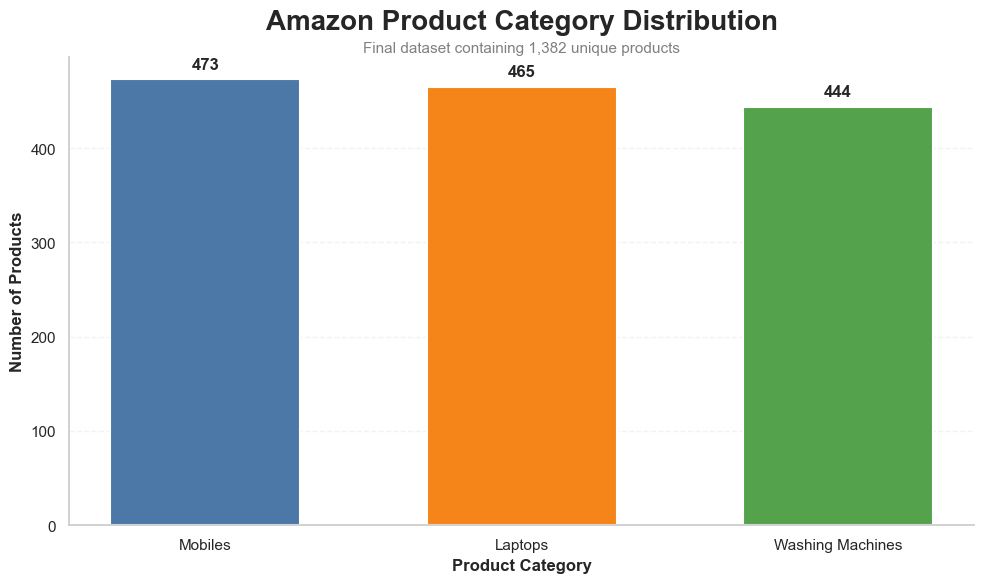

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Category counts
category_counts = amazon["Category"].value_counts()

# Professional theme
sns.set_theme(style="whitegrid")

# Color palette
colors = ["#4C78A8", "#F58518", "#54A24B"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    range(len(category_counts)),
    category_counts.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# Correct tick positions + labels
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(
    ["Mobiles", "Laptops", "Washing Machines"],
    fontsize=11
)

# Add values
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Amazon Product Category Distribution",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Final dataset containing 1,382 unique products",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Axis labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

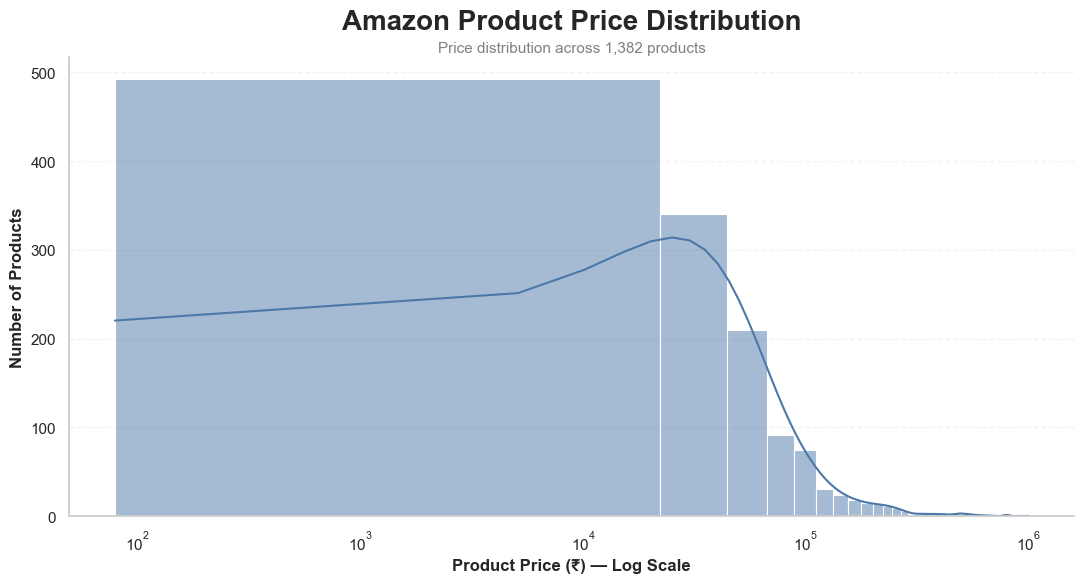

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

price = amazon["Price_Numeric"].dropna()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

# Histogram
sns.histplot(
    price,
    bins=45,
    kde=True,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Log scale because price has a long right tail
ax.set_xscale("log")

# Title
ax.set_title(
    "Amazon Product Price Distribution",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Price distribution across 1,382 products",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Price (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

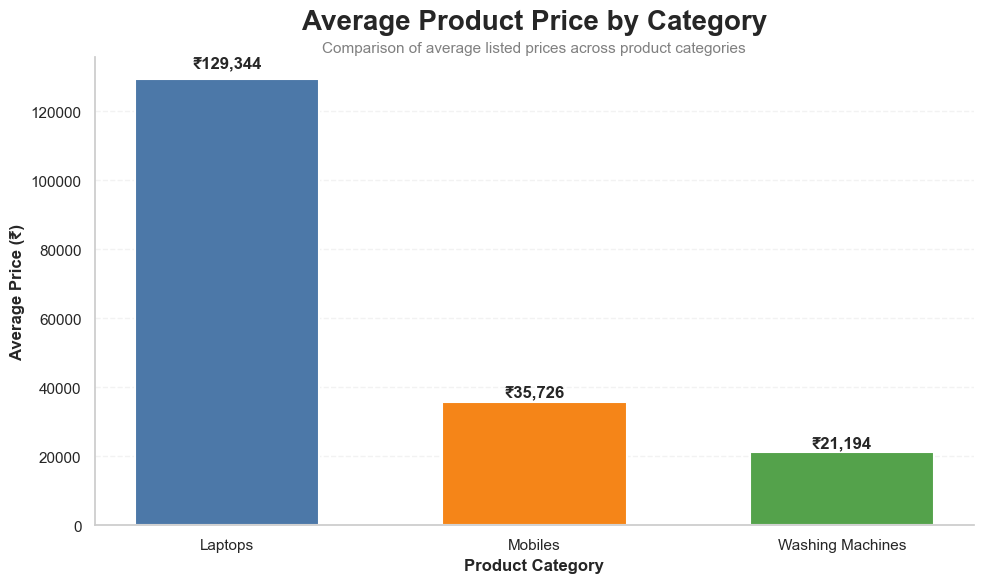

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Calculate average price
avg_price = (
    amazon.groupby("Category")["Price_Numeric"]
    .mean()
    .sort_values(ascending=False)
)

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B"]

bars = ax.bar(
    range(len(avg_price)),
    avg_price.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# X-axis
ax.set_xticks(range(len(avg_price)))
ax.set_xticklabels(
    ["Laptops", "Mobiles", "Washing Machines"],
    fontsize=11
)

# Value labels
for bar, value in zip(bars, avg_price.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (value * 0.02),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Average Product Price by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparison of average listed prices across product categories",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Axis labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Price (₹)",
    fontsize=12,
    fontweight="bold"
)

# Clean chart
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

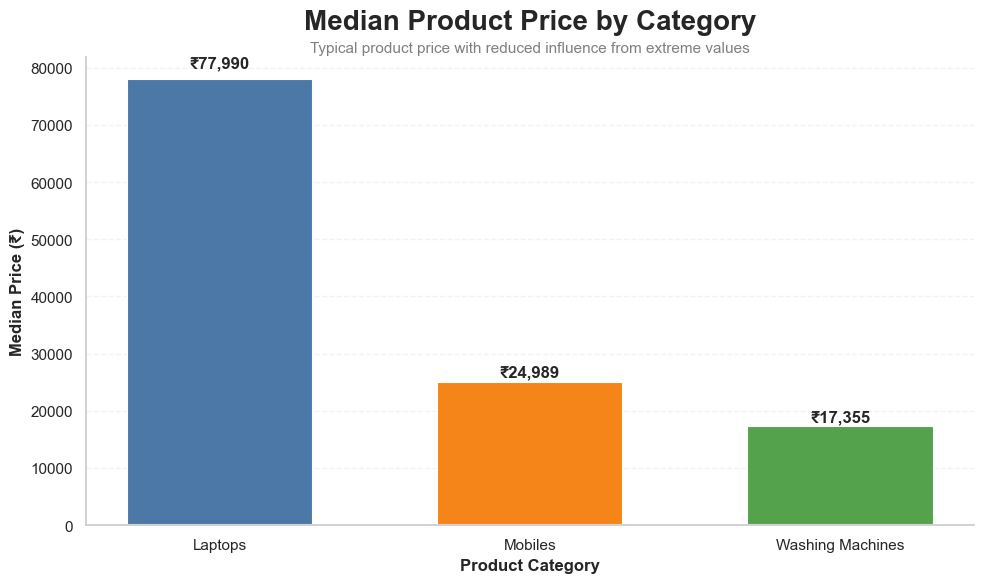

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Median price
median_price = (
    amazon.groupby("Category")["Price_Numeric"]
    .median()
    .sort_values(ascending=False)
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B"]

bars = ax.bar(
    range(len(median_price)),
    median_price.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# Category labels
ax.set_xticks(range(len(median_price)))
ax.set_xticklabels(
    ["Laptops", "Mobiles", "Washing Machines"],
    fontsize=11
)

# Value labels
for bar, value in zip(bars, median_price.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + value * 0.02,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Median Product Price by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Typical product price with reduced influence from extreme values",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Median Price (₹)",
    fontsize=12,
    fontweight="bold"
)

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

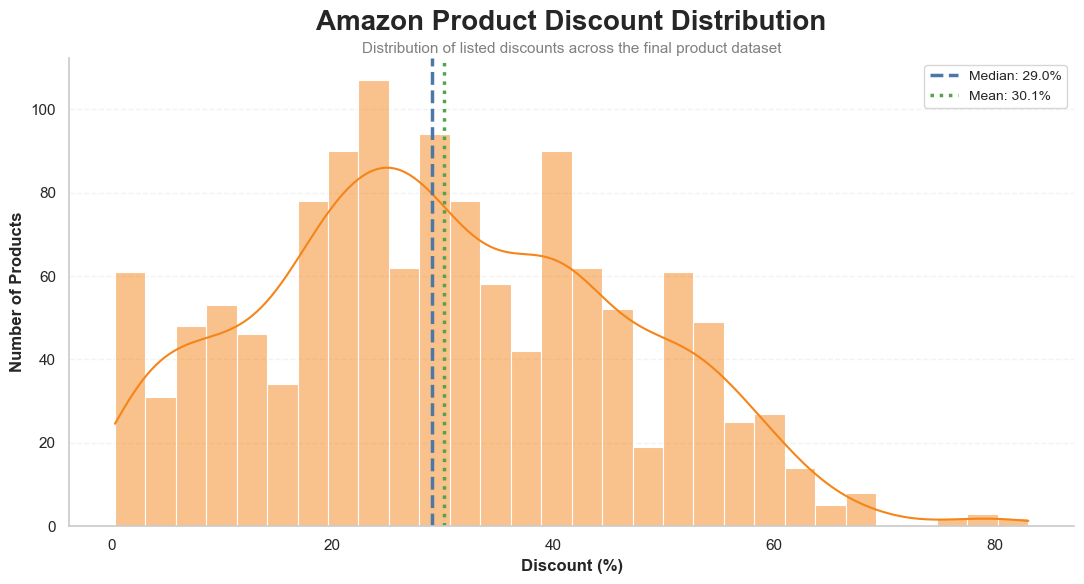

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

discount = amazon["Discount_Pct_Final"].dropna()

# Key statistics
median_discount = discount.median()
mean_discount = discount.mean()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

# Distribution
sns.histplot(
    discount,
    bins=30,
    kde=True,
    color="#F58518",
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Median reference line
ax.axvline(
    median_discount,
    color="#4C78A8",
    linestyle="--",
    linewidth=2.5,
    label=f"Median: {median_discount:.1f}%"
)

# Mean reference line
ax.axvline(
    mean_discount,
    color="#54A24B",
    linestyle=":",
    linewidth=2.5,
    label=f"Mean: {mean_discount:.1f}%"
)

# Title
ax.set_title(
    "Amazon Product Discount Distribution",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Distribution of listed discounts across the final product dataset",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Discount (%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Legend
ax.legend(
    frameon=True,
    fontsize=10
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

AVERAGE DISCOUNT BY CATEGORY
Category
washing_machines    33.23
laptops             31.96
mobiles             25.05
Name: Discount_Pct_Final, dtype: float64


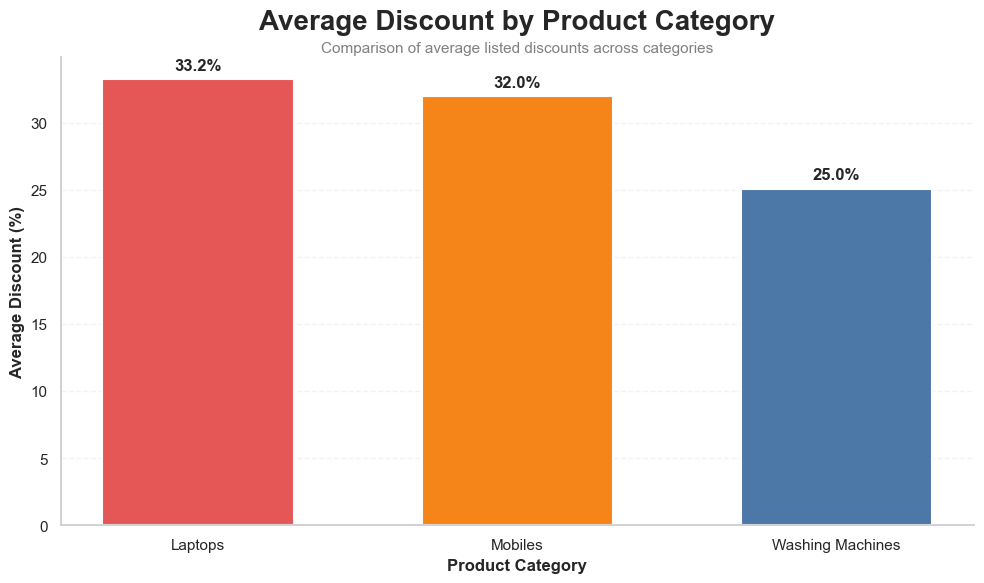

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Calculate average discount by category
avg_discount = (
    amazon.groupby("Category")["Discount_Pct_Final"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE DISCOUNT BY CATEGORY")
print(avg_discount.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#E45756", "#F58518", "#4C78A8"]

bars = ax.bar(
    range(len(avg_discount)),
    avg_discount.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# Category labels
ax.set_xticks(range(len(avg_discount)))
ax.set_xticklabels(
    ["Laptops", "Mobiles", "Washing Machines"],
    fontsize=11
)

# Value labels
for bar, value in zip(bars, avg_discount.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Average Discount by Product Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparison of average listed discounts across categories",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Discount (%)",
    fontsize=12,
    fontweight="bold"
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

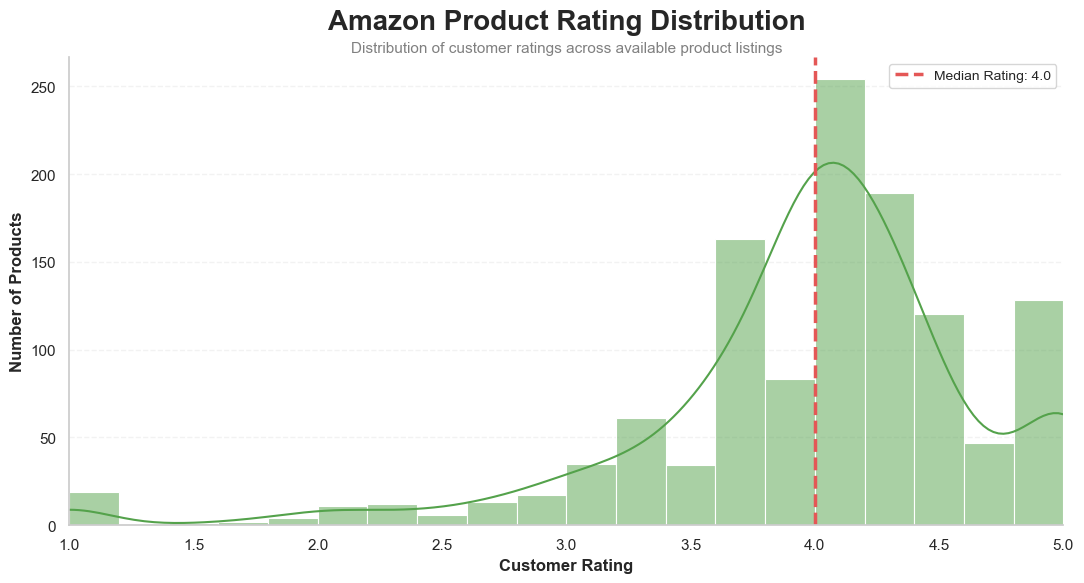

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

rating = amazon["Rating_Numeric"].dropna()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

# Rating distribution
sns.histplot(
    rating,
    bins=20,
    kde=True,
    color="#54A24B",
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Median rating
median_rating = rating.median()

ax.axvline(
    median_rating,
    color="#E45756",
    linestyle="--",
    linewidth=2.5,
    label=f"Median Rating: {median_rating:.1f}"
)

# Title
ax.set_title(
    "Amazon Product Rating Distribution",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Distribution of customer ratings across available product listings",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Customer Rating",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Rating scale
ax.set_xlim(1, 5)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

AVERAGE RATING BY CATEGORY
Category
laptops             3.92
mobiles             3.93
washing_machines    4.05
Name: Rating_Numeric, dtype: float64


C:\Users\banu\AppData\Local\Temp\ipykernel_8868\1240056629.py:102: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


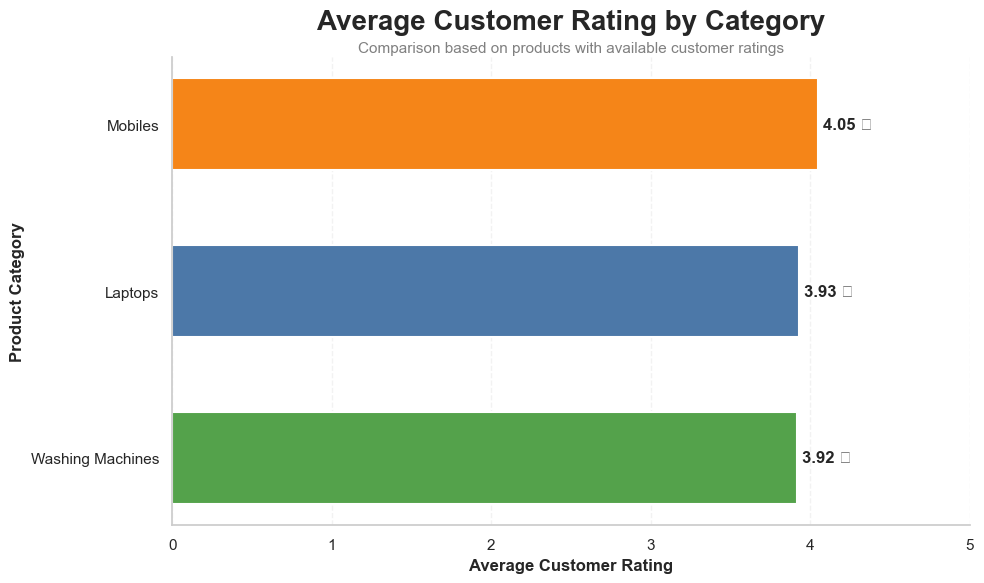

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Average rating by category
avg_rating = (
    amazon.groupby("Category")["Rating_Numeric"]
    .mean()
    .sort_values(ascending=True)
)

print("AVERAGE RATING BY CATEGORY")
print(avg_rating.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#54A24B", "#4C78A8", "#F58518"]

bars = ax.barh(
    range(len(avg_rating)),
    avg_rating.values,
    color=colors,
    height=0.55,
    edgecolor="white",
    linewidth=1.5
)

# Category labels
ax.set_yticks(range(len(avg_rating)))
ax.set_yticklabels(
    ["Washing Machines", "Laptops", "Mobiles"],
    fontsize=11
)

# Value labels
for bar, value in zip(bars, avg_rating.values):
    ax.text(
        value + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f} ★",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Rating scale
ax.set_xlim(0, 5)

# Title
ax.set_title(
    "Average Customer Rating by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparison based on products with available customer ratings",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Average Customer Rating",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()
plt.show()

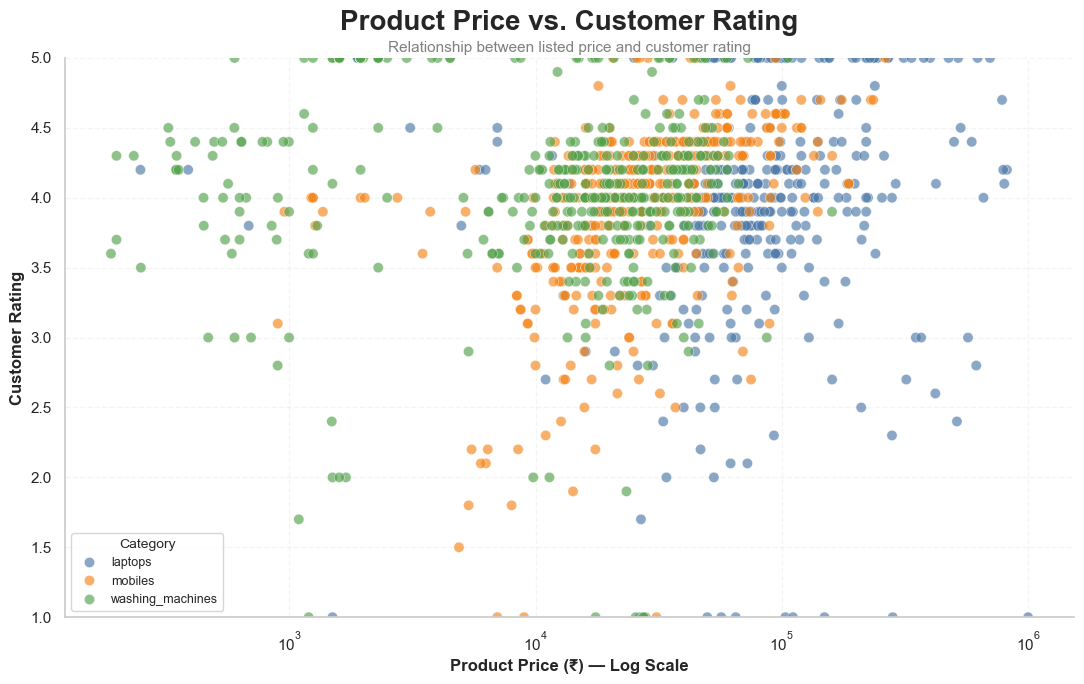

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep rows where both price and rating are available
plot_data = amazon[
    amazon["Price_Numeric"].notna() &
    amazon["Rating_Numeric"].notna()
].copy()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

# Scatter plot
sns.scatterplot(
    data=plot_data,
    x="Price_Numeric",
    y="Rating_Numeric",
    hue="Category",
    palette={
        "laptops": "#4C78A8",
        "mobiles": "#F58518",
        "washing_machines": "#54A24B"
    },
    alpha=0.65,
    s=55,
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

# Log scale because prices have a very wide range
ax.set_xscale("log")

# Title
ax.set_title(
    "Product Price vs. Customer Rating",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Relationship between listed price and customer rating",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Axis labels
ax.set_xlabel(
    "Product Price (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Customer Rating",
    fontsize=12,
    fontweight="bold"
)

# Rating limits
ax.set_ylim(1, 5)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.2
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    title="Category",
    frameon=True,
    title_fontsize=10,
    fontsize=9
)

plt.tight_layout()
plt.show()

Price–Rating Correlation: 0.047

CATEGORY-WISE CORRELATION
Category
laptops             0.055
mobiles             0.382
washing_machines   -0.032
dtype: float64


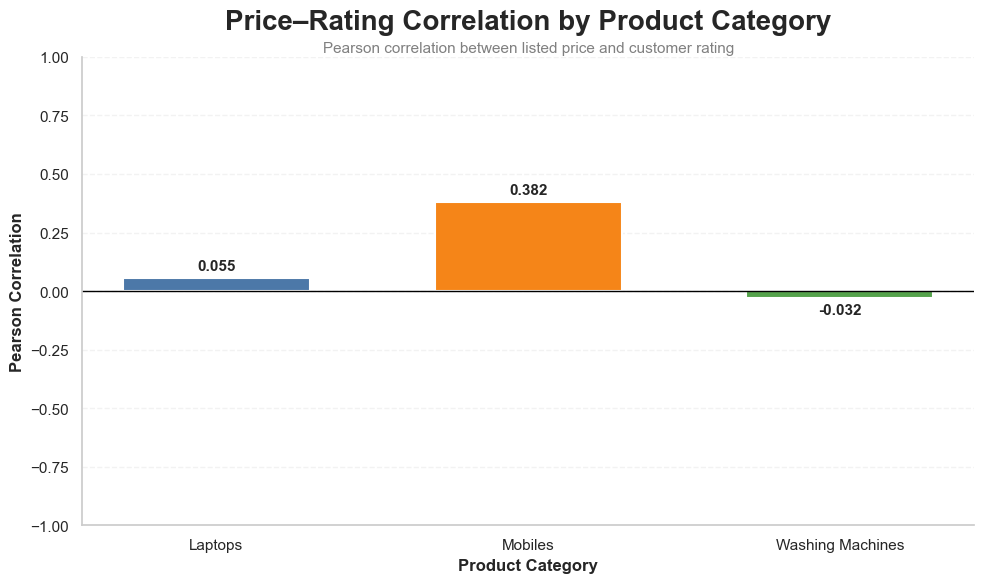

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid price and rating values
corr_data = amazon[
    amazon["Price_Numeric"].notna() &
    amazon["Rating_Numeric"].notna()
].copy()

# Overall Pearson correlation
correlation = corr_data["Price_Numeric"].corr(
    corr_data["Rating_Numeric"]
)

print(f"Price–Rating Correlation: {correlation:.3f}")

# Category-wise correlation
category_corr = (
    corr_data
    .groupby("Category")
    .apply(
        lambda x: x["Price_Numeric"].corr(x["Rating_Numeric"]),
        include_groups=False
    )
)

print("\nCATEGORY-WISE CORRELATION")
print(category_corr.round(3))

# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B"]

bars = ax.bar(
    range(len(category_corr)),
    category_corr.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# X labels
ax.set_xticks(range(len(category_corr)))
ax.set_xticklabels(
    ["Laptops", "Mobiles", "Washing Machines"],
    fontsize=11
)

# Zero reference line
ax.axhline(
    0,
    color="black",
    linewidth=1
)

# Value labels
for bar, value in zip(bars, category_corr.values):
    if value >= 0:
        y_position = value + 0.02
        va = "bottom"
    else:
        y_position = value - 0.02
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.3f}",
        ha="center",
        va=va,
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Price–Rating Correlation by Product Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.text(
    0.5,
    1.01,
    "Pearson correlation between listed price and customer rating",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Pearson Correlation",
    fontsize=12,
    fontweight="bold"
)

# Correlation range
ax.set_ylim(-1, 1)

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

PRICE SUMMARY
                       mean   median
Category                            
laptops           129344.41  77990.0
mobiles            35725.86  24989.0
washing_machines   21194.11  17355.0


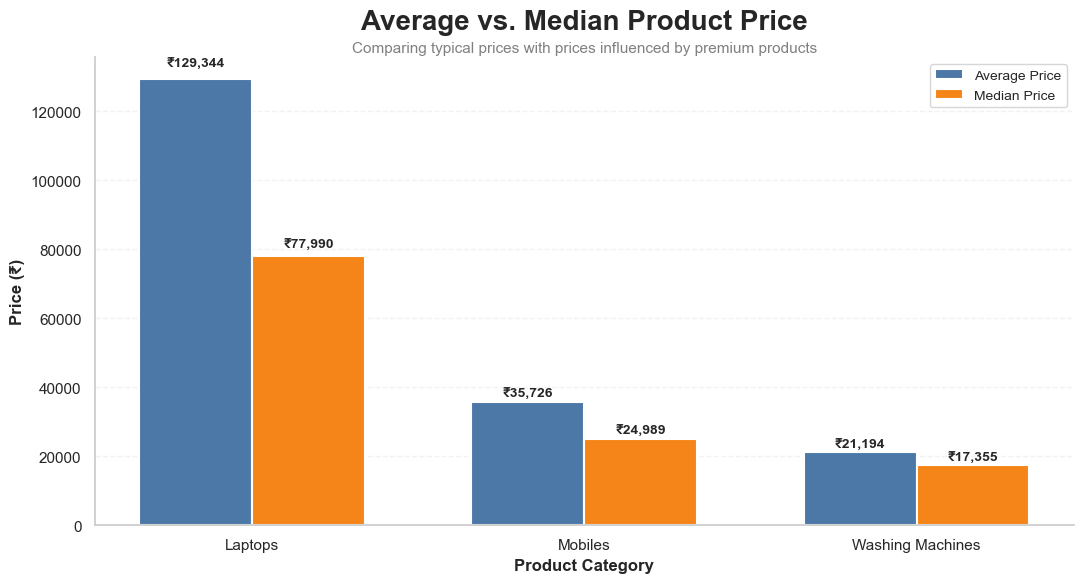

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Calculate mean and median
price_summary = (
    amazon.groupby("Category")["Price_Numeric"]
    .agg(["mean", "median"])
)

# Keep a consistent category order
category_order = ["laptops", "mobiles", "washing_machines"]
price_summary = price_summary.reindex(category_order)

print("PRICE SUMMARY")
print(price_summary.round(2))

# Plot
sns.set_theme(style="whitegrid")

x = np.arange(len(price_summary))
width = 0.34

fig, ax = plt.subplots(figsize=(11, 6))

mean_bars = ax.bar(
    x - width / 2,
    price_summary["mean"],
    width,
    label="Average Price",
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.5
)

median_bars = ax.bar(
    x + width / 2,
    price_summary["median"],
    width,
    label="Median Price",
    color="#F58518",
    edgecolor="white",
    linewidth=1.5
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    ["Laptops", "Mobiles", "Washing Machines"],
    fontsize=11
)

# Value labels
for bars in [mean_bars, median_bars]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + height * 0.02,
            f"₹{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Title
ax.set_title(
    "Average vs. Median Product Price",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparing typical prices with prices influenced by premium products",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Price (₹)",
    fontsize=12,
    fontweight="bold"
)

# Legend
ax.legend(
    frameon=True,
    fontsize=10
)

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

REVIEW COUNT STATISTICS
Mean Reviews   : 14,383
Median Reviews : 34
Maximum Reviews: 912,887


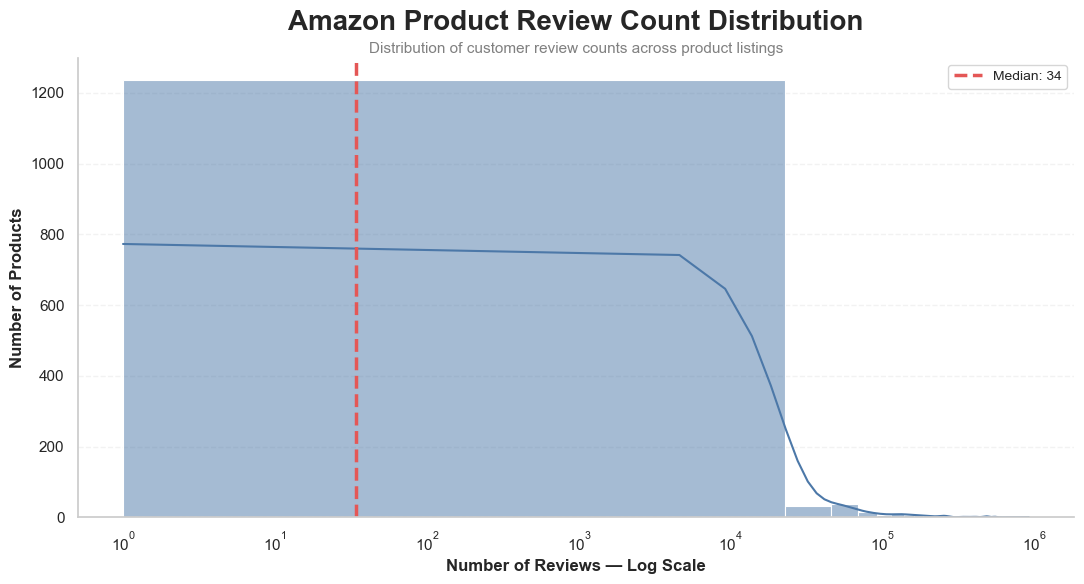

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

reviews = amazon["Reviews_Numeric"].dropna()

# Remove zero values for log-scale visualization
reviews = reviews[reviews > 0]

# Statistics
median_reviews = reviews.median()
mean_reviews = reviews.mean()

print("REVIEW COUNT STATISTICS")
print(f"Mean Reviews   : {mean_reviews:,.0f}")
print(f"Median Reviews : {median_reviews:,.0f}")
print(f"Maximum Reviews: {reviews.max():,.0f}")

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    reviews,
    bins=40,
    kde=True,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Log scale
ax.set_xscale("log")

# Median reference
ax.axvline(
    median_reviews,
    color="#E45756",
    linestyle="--",
    linewidth=2.5,
    label=f"Median: {median_reviews:,.0f}"
)

# Title
ax.set_title(
    "Amazon Product Review Count Distribution",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Distribution of customer review counts across product listings",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Number of Reviews — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

ax.legend(
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

Review Count–Rating Correlation: 0.082


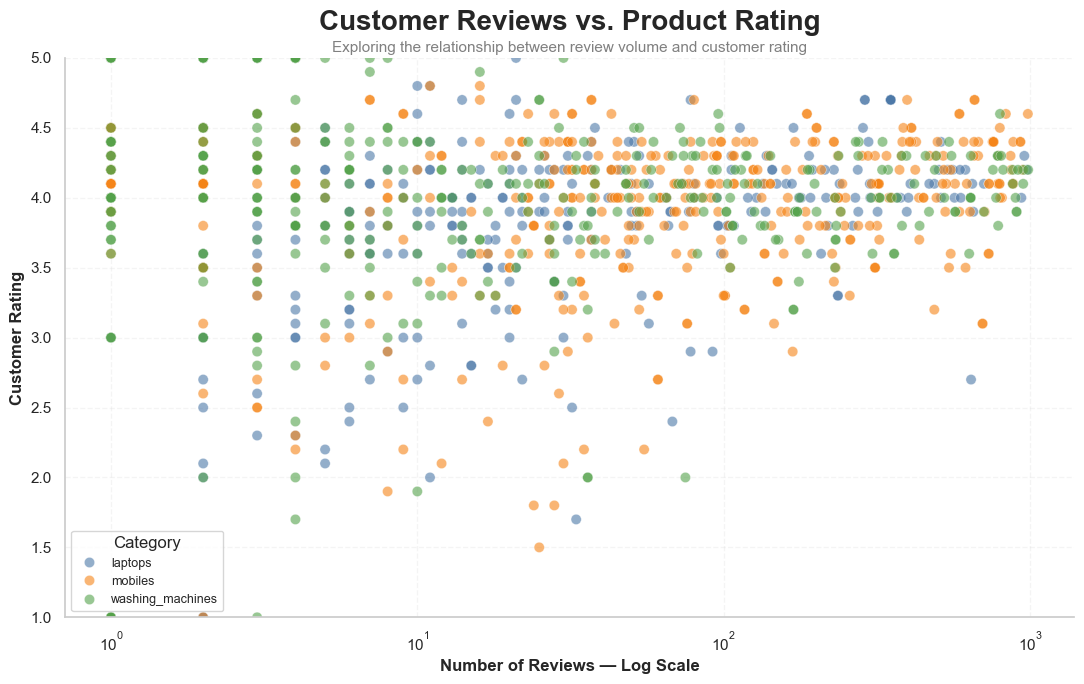

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid review and rating values
plot_data = amazon[
    amazon["Reviews_Numeric"].notna() &
    amazon["Rating_Numeric"].notna() &
    (amazon["Reviews_Numeric"] > 0)
].copy()

# Correlation
correlation = plot_data["Reviews_Numeric"].corr(
    plot_data["Rating_Numeric"]
)

print(f"Review Count–Rating Correlation: {correlation:.3f}")

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=plot_data,
    x="Reviews_Numeric",
    y="Rating_Numeric",
    hue="Category",
    palette={
        "laptops": "#4C78A8",
        "mobiles": "#F58518",
        "washing_machines": "#54A24B"
    },
    alpha=0.6,
    s=55,
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

# Log scale for reviews
ax.set_xscale("log")

# Rating range
ax.set_ylim(1, 5)

# Title
ax.set_title(
    "Customer Reviews vs. Product Rating",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Exploring the relationship between review volume and customer rating",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Number of Reviews — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Customer Rating",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.2
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    title="Category",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()

AVERAGE REVIEW COUNT BY CATEGORY
Category
laptops             38852.0
washing_machines     2690.0
mobiles              1303.0
Name: Reviews_Numeric, dtype: float64


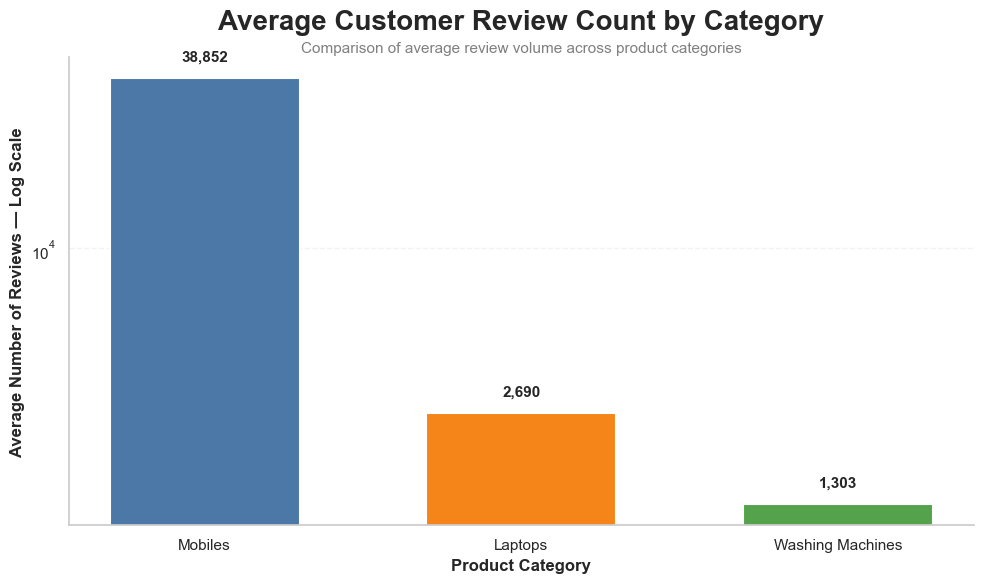

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Average reviews by category
avg_reviews = (
    amazon.groupby("Category")["Reviews_Numeric"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE REVIEW COUNT BY CATEGORY")
print(avg_reviews.round(0))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B"]

bars = ax.bar(
    range(len(avg_reviews)),
    avg_reviews.values,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# Category labels
ax.set_xticks(range(len(avg_reviews)))
ax.set_xticklabels(
    ["Mobiles", "Laptops", "Washing Machines"],
    fontsize=11
)

# Log scale
ax.set_yscale("log")

# Value labels
for bar, value in zip(bars, avg_reviews.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.12,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Average Customer Review Count by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparison of average review volume across product categories",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Number of Reviews — Log Scale",
    fontsize=12,
    fontweight="bold"
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()
plt.show()

C:\Users\banu\AppData\Local\Temp\ipykernel_8868\2764829034.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


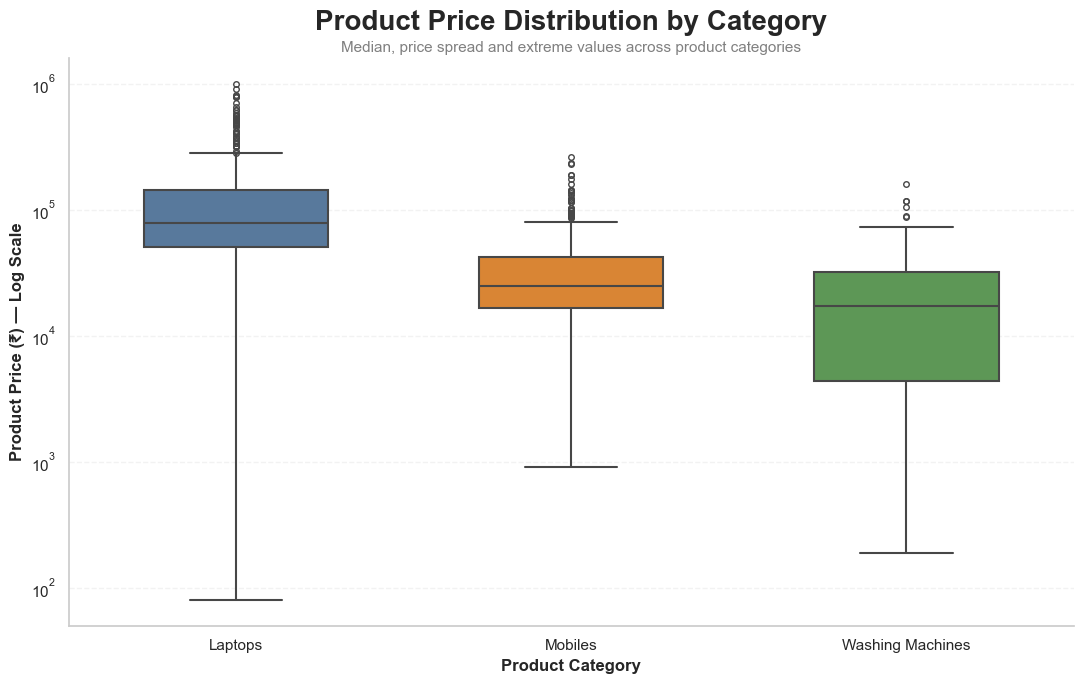

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Category order
category_order = [
    "laptops",
    "mobiles",
    "washing_machines"
]

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

# Box plot
sns.boxplot(
    data=amazon,
    x="Category",
    y="Price_Numeric",
    order=category_order,
    hue="Category",
    palette=["#4C78A8", "#F58518", "#54A24B"],
    legend=False,
    width=0.55,
    linewidth=1.5,
    fliersize=4,
    ax=ax
)

# Log scale because prices span a very wide range
ax.set_yscale("log")

# Clean category names
ax.set_xticklabels([
    "Laptops",
    "Mobiles",
    "Washing Machines"
])

# Title
ax.set_title(
    "Product Price Distribution by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Median, price spread and extreme values across product categories",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Product Price (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

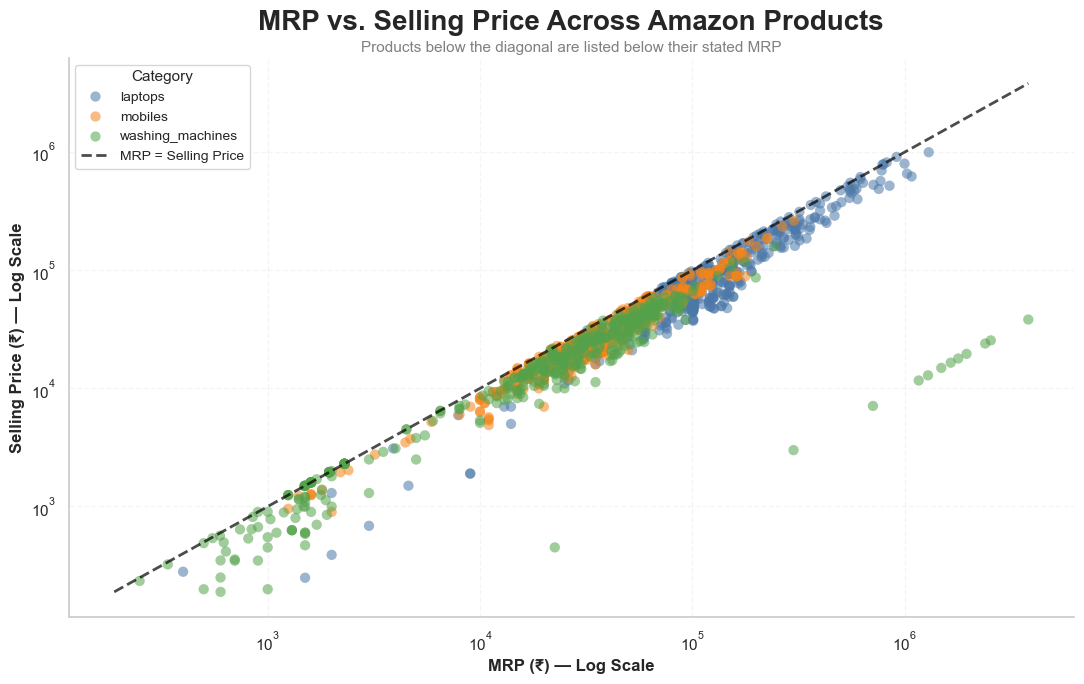

Products plotted: 1,301


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep products where both MRP and selling price are available
plot_data = amazon.dropna(
    subset=["MRP_Numeric", "Price_Numeric"]
).copy()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

# Category colors
palette = {
    "laptops": "#4C78A8",
    "mobiles": "#F58518",
    "washing_machines": "#54A24B"
}

# Scatter plot
sns.scatterplot(
    data=plot_data,
    x="MRP_Numeric",
    y="Price_Numeric",
    hue="Category",
    palette=palette,
    alpha=0.55,
    s=55,
    edgecolor="none",
    ax=ax
)

# Reference line: Selling Price = MRP
min_value = min(
    plot_data["MRP_Numeric"].min(),
    plot_data["Price_Numeric"].min()
)

max_value = max(
    plot_data["MRP_Numeric"].max(),
    plot_data["Price_Numeric"].max()
)

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.7,
    label="MRP = Selling Price"
)

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Title
ax.set_title(
    "MRP vs. Selling Price Across Amazon Products",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Products below the diagonal are listed below their stated MRP",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Axis labels
ax.set_xlabel(
    "MRP (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Selling Price (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

# Legend
legend = ax.legend(
    title="Category",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.20
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Products plotted: {len(plot_data):,}")

AVERAGE SAVINGS BY CATEGORY
Category
laptops             47015.63
mobiles             11905.79
washing_machines    52423.82
Name: Savings, dtype: float64


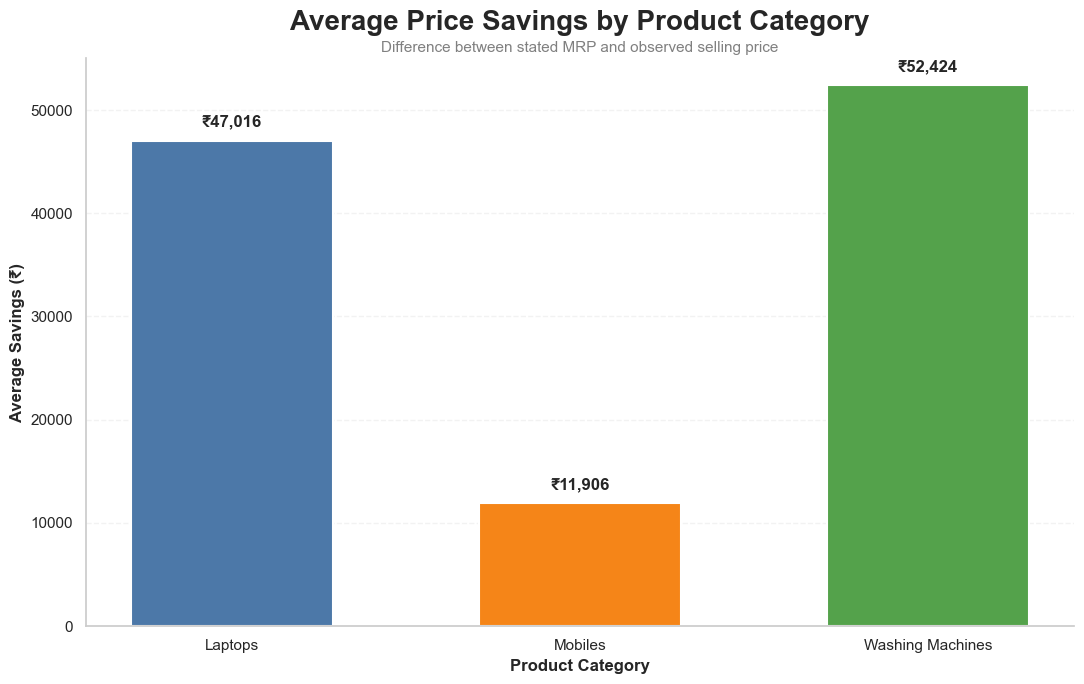


Products analyzed: 1,301


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep rows with both MRP and selling price
plot_data = amazon.dropna(
    subset=["MRP_Numeric", "Price_Numeric"]
).copy()

# Calculate absolute savings
plot_data["Savings"] = (
    plot_data["MRP_Numeric"] - plot_data["Price_Numeric"]
)

# Keep only valid savings
plot_data = plot_data[plot_data["Savings"] >= 0].copy()

# Average savings by category
category_order = [
    "laptops",
    "mobiles",
    "washing_machines"
]

avg_savings = (
    plot_data.groupby("Category")["Savings"]
    .mean()
    .reindex(category_order)
)

print("AVERAGE SAVINGS BY CATEGORY")
print(avg_savings.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B"
]

bars = ax.bar(
    ["Laptops", "Mobiles", "Washing Machines"],
    avg_savings.values,
    color=colors,
    width=0.58,
    edgecolor="white",
    linewidth=1.5
)

# Value labels
for bar, value in zip(bars, avg_savings.values):
    ax.annotate(
        f"₹{value:,.0f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Average Price Savings by Product Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Difference between stated MRP and observed selling price",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Axis labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Savings (₹)",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nProducts analyzed: {len(plot_data):,}")

CATEGORY PRICING METRICS
                  Average_Price  Average_Discount
Category                                         
laptops               129344.41             31.96
mobiles                35725.86             25.05
washing_machines       21194.11             33.23


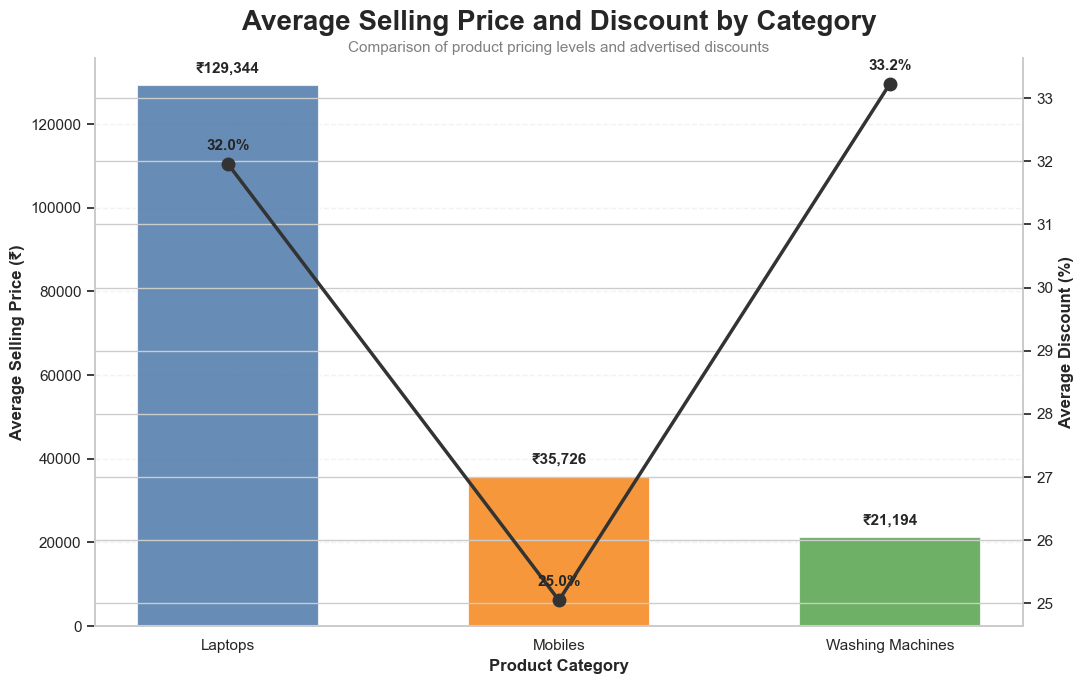

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Category order
category_order = [
    "laptops",
    "mobiles",
    "washing_machines"
]

# Calculate category-level metrics
category_metrics = (
    amazon.groupby("Category")
    .agg(
        Average_Price=("Price_Numeric", "mean"),
        Average_Discount=("Discount_Pct_Final", "mean")
    )
    .reindex(category_order)
)

print("CATEGORY PRICING METRICS")
print(category_metrics.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(11, 7))

x = range(len(category_metrics))

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B"
]

# Average price bars
bars = ax1.bar(
    x,
    category_metrics["Average_Price"],
    width=0.55,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5
)

# Price labels
for bar, value in zip(
    bars,
    category_metrics["Average_Price"]
):
    ax1.annotate(
        f"₹{value:,.0f}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Second axis for discount
ax2 = ax1.twinx()

ax2.plot(
    x,
    category_metrics["Average_Discount"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color="#333333",
    label="Average Discount"
)

# Discount labels
for i, value in enumerate(
    category_metrics["Average_Discount"]
):
    ax2.annotate(
        f"{value:.1f}%",
        xy=(i, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(
    [
        "Laptops",
        "Mobiles",
        "Washing Machines"
    ],
    fontsize=11
)

# Labels
ax1.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax1.set_ylabel(
    "Average Selling Price (₹)",
    fontsize=12,
    fontweight="bold"
)

ax2.set_ylabel(
    "Average Discount (%)",
    fontsize=12,
    fontweight="bold"
)

# Title
ax1.set_title(
    "Average Selling Price and Discount by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax1.text(
    0.5,
    1.01,
    "Comparison of product pricing levels and advertised discounts",
    transform=ax1.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Grid
ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax1.grid(
    axis="x",
    visible=False
)

# Clean borders
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

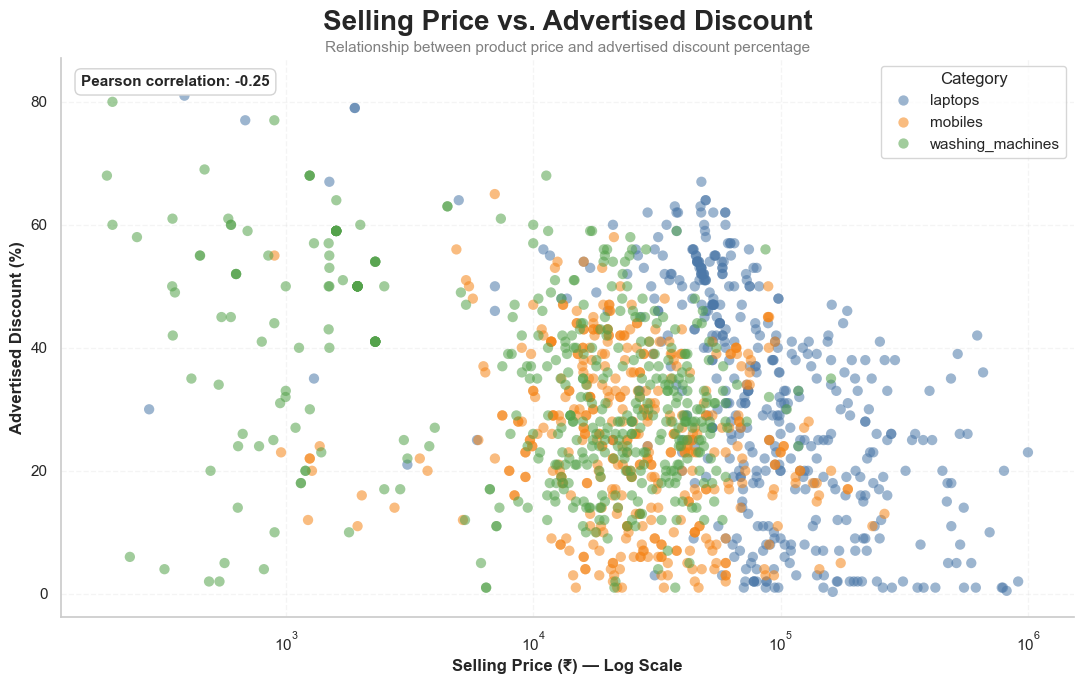

Products analyzed: 1,301
Overall Pearson correlation: -0.247


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid price and discount values
plot_data = amazon.dropna(
    subset=["Price_Numeric", "Discount_Pct_Final"]
).copy()

# Keep realistic discount range
plot_data = plot_data[
    (plot_data["Discount_Pct_Final"] >= 0) &
    (plot_data["Discount_Pct_Final"] <= 100)
].copy()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

palette = {
    "laptops": "#4C78A8",
    "mobiles": "#F58518",
    "washing_machines": "#54A24B"
}

# Scatter plot
sns.scatterplot(
    data=plot_data,
    x="Price_Numeric",
    y="Discount_Pct_Final",
    hue="Category",
    palette=palette,
    alpha=0.55,
    s=55,
    edgecolor="none",
    ax=ax
)

# Log scale for price
ax.set_xscale("log")

# Overall correlation
correlation = plot_data[
    ["Price_Numeric", "Discount_Pct_Final"]
].corr().iloc[0, 1]

# Correlation annotation
ax.text(
    0.02,
    0.95,
    f"Pearson correlation: {correlation:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    )
)

# Title
ax.set_title(
    "Selling Price vs. Advertised Discount",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Relationship between product price and advertised discount percentage",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Selling Price (₹) — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Advertised Discount (%)",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.20
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Products analyzed: {len(plot_data):,}")
print(f"Overall Pearson correlation: {correlation:.3f}")

TOP 10 BRANDS BY PRODUCT COUNT
Brand
Samsung     175
HP          120
Lenovo      113
ASUS         58
Acer         55
Realme       50
Motorola     49
SeMi         47
LG           44
Dell         39
Name: count, dtype: int64


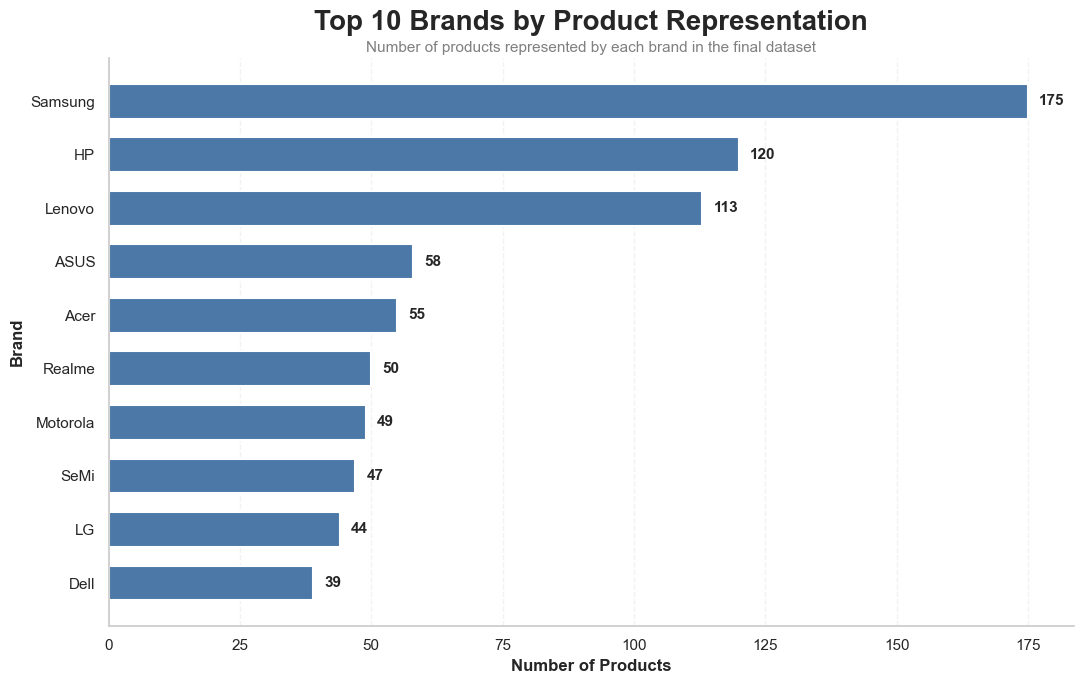

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Count products by brand
brand_counts = (
    amazon["Brand"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(10)
)

print("TOP 10 BRANDS BY PRODUCT COUNT")
print(brand_counts)

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    brand_counts.index[::-1],
    brand_counts.values[::-1],
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.5,
    height=0.65
)

# Value labels
for bar, value in zip(
    bars,
    brand_counts.values[::-1]
):
    ax.annotate(
        f"{value}",
        xy=(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 10 Brands by Product Representation",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Number of products represented by each brand in the final dataset",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

TOP 10 BRANDS BY AVERAGE RATING
            Average_Rating  Product_Count
Brand                                    
IFB                   4.15             31
LG                    4.16             42
Realme                4.18             50
OnePlus               4.24             27
Xiaomi                4.28              5
Ariel                 4.34              5
Electrolux            4.39              7
Surf                  4.42              5
Apple                 4.46             19
SeMi                  4.66             44


C:\Users\banu\AppData\Local\Temp\ipykernel_8868\3642700462.py:132: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


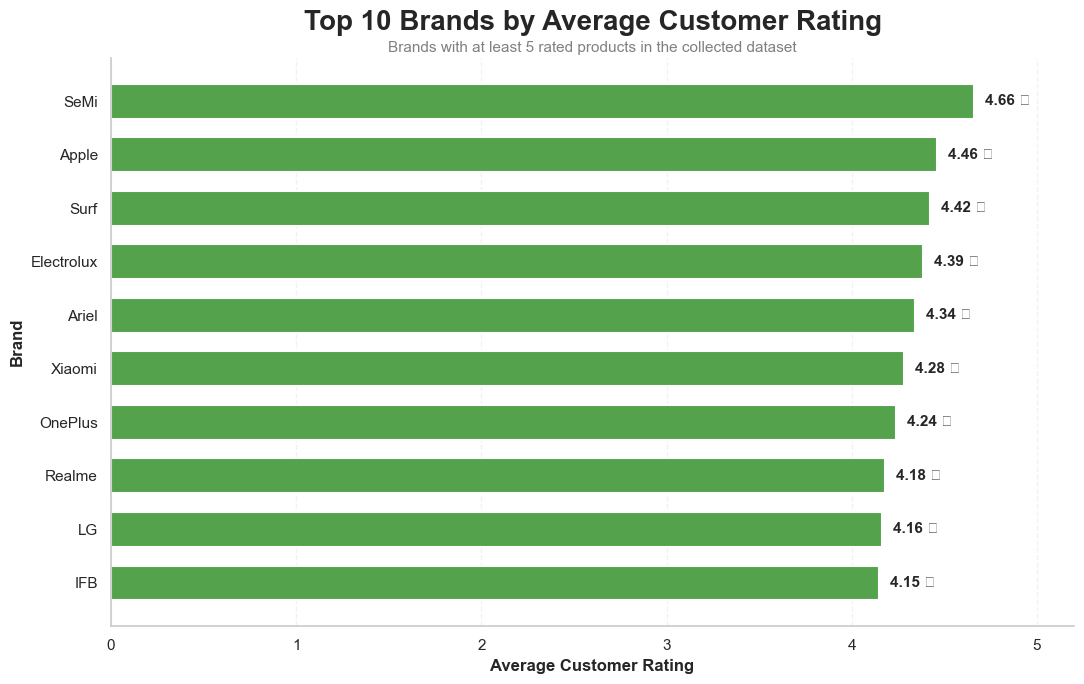

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid ratings and brands
rating_data = amazon.dropna(
    subset=["Brand", "Rating_Numeric"]
).copy()

# Keep valid rating range
rating_data = rating_data[
    (rating_data["Rating_Numeric"] >= 0) &
    (rating_data["Rating_Numeric"] <= 5)
]

# Calculate brand-level statistics
brand_rating = (
    rating_data
    .groupby("Brand")
    .agg(
        Average_Rating=("Rating_Numeric", "mean"),
        Product_Count=("Rating_Numeric", "count")
    )
)

# Require at least 5 products per brand
brand_rating = brand_rating[
    brand_rating["Product_Count"] >= 5
]

# Top 10 brands by average rating
top_brands = (
    brand_rating
    .sort_values(
        "Average_Rating",
        ascending=False
    )
    .head(10)
    .sort_values("Average_Rating")
)

print("TOP 10 BRANDS BY AVERAGE RATING")
print(top_brands.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_brands.index,
    top_brands["Average_Rating"],
    color="#54A24B",
    edgecolor="white",
    linewidth=1.5,
    height=0.65
)

# Rating labels
for bar, rating in zip(
    bars,
    top_brands["Average_Rating"]
):
    ax.annotate(
        f"{rating:.2f} ★",
        xy=(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Rating scale
ax.set_xlim(0, 5.2)

# Title
ax.set_title(
    "Top 10 Brands by Average Customer Rating",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Brands with at least 5 rated products in the collected dataset",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Average Customer Rating",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

TOP 10 BRANDS BY AVERAGE PRICE
           Average_Price  Product_Count
Brand                                  
Vivo            51299.30             30
Acer            74825.91             55
HP              80526.63            120
Xiaomi          80597.20              5
Dell           140446.82             39
Lenovo         161893.68            113
MSI            170164.31             13
ASUS           184855.78             58
Apple          203172.11             19
Alienware      487363.75              8


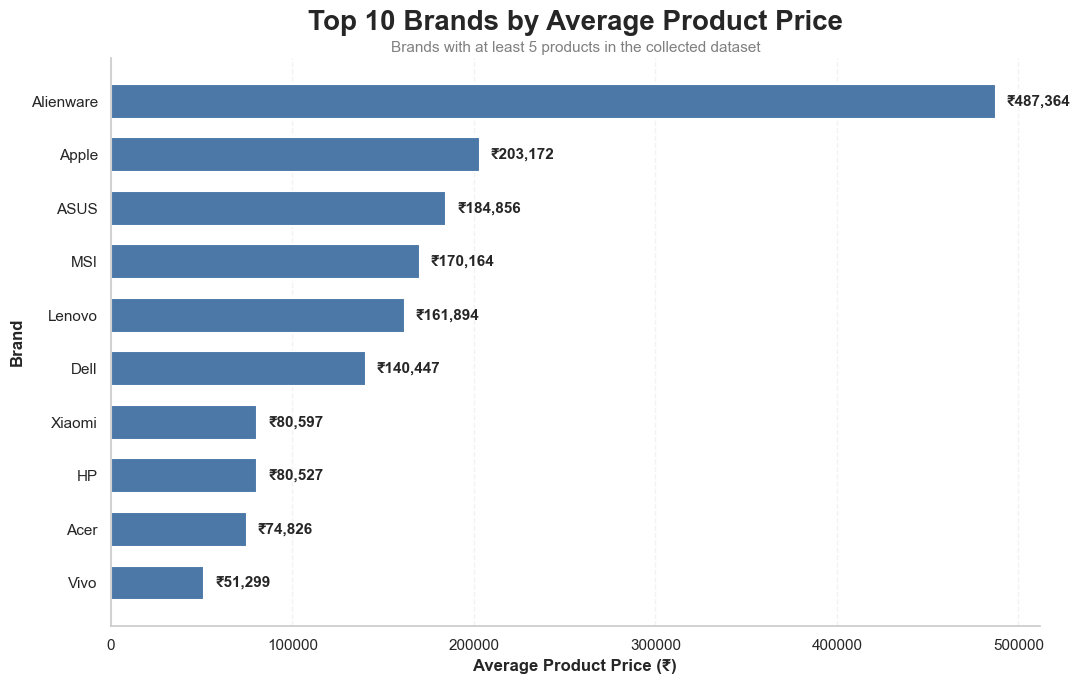

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid brand and price values
price_data = amazon.dropna(
    subset=["Brand", "Price_Numeric"]
).copy()

# Calculate brand-level statistics
brand_price = (
    price_data
    .groupby("Brand")
    .agg(
        Average_Price=("Price_Numeric", "mean"),
        Product_Count=("Price_Numeric", "count")
    )
)

# Require at least 5 products per brand
brand_price = brand_price[
    brand_price["Product_Count"] >= 5
]

# Top 10 brands by average price
top_brands = (
    brand_price
    .sort_values(
        "Average_Price",
        ascending=False
    )
    .head(10)
    .sort_values("Average_Price")
)

print("TOP 10 BRANDS BY AVERAGE PRICE")
print(top_brands.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_brands.index,
    top_brands["Average_Price"],
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.5,
    height=0.65
)

# Value labels
for bar, value in zip(
    bars,
    top_brands["Average_Price"]
):
    ax.annotate(
        f"₹{value:,.0f}",
        xy=(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 10 Brands by Average Product Price",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Brands with at least 5 products in the collected dataset",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Average Product Price (₹)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

TOP 10 MOST REVIEWED PRODUCTS
Category     Brand                                                       Product_Title  Reviews_Numeric  Rating_Numeric
 laptops  GIGABYTE                               GIGABYTE AORUS Master 16 BZHC6INE64SH         450990.0             NaN
 laptops      ASUS                                                     ASUS ProArt P16         469990.0             NaN
 laptops Alienware                                Alienware Dell Area 51 Gaming Laptop         472990.0             NaN
 laptops    Lenovo Lenovo Legion Pro 7 Intel Core Ultra 9 290HX | NVIDIA RTX 5080 16GB         488490.0             NaN
 laptops      ASUS                                              ASUS ROG Strix Scar 18         489990.0             NaN
 laptops      ASUS                                               ASUS ROG Zephyrus G16         489990.0             NaN
 laptops      ASUS                                               ASUS ROG Zephyrus G16         529990.0             NaN
 laptops  

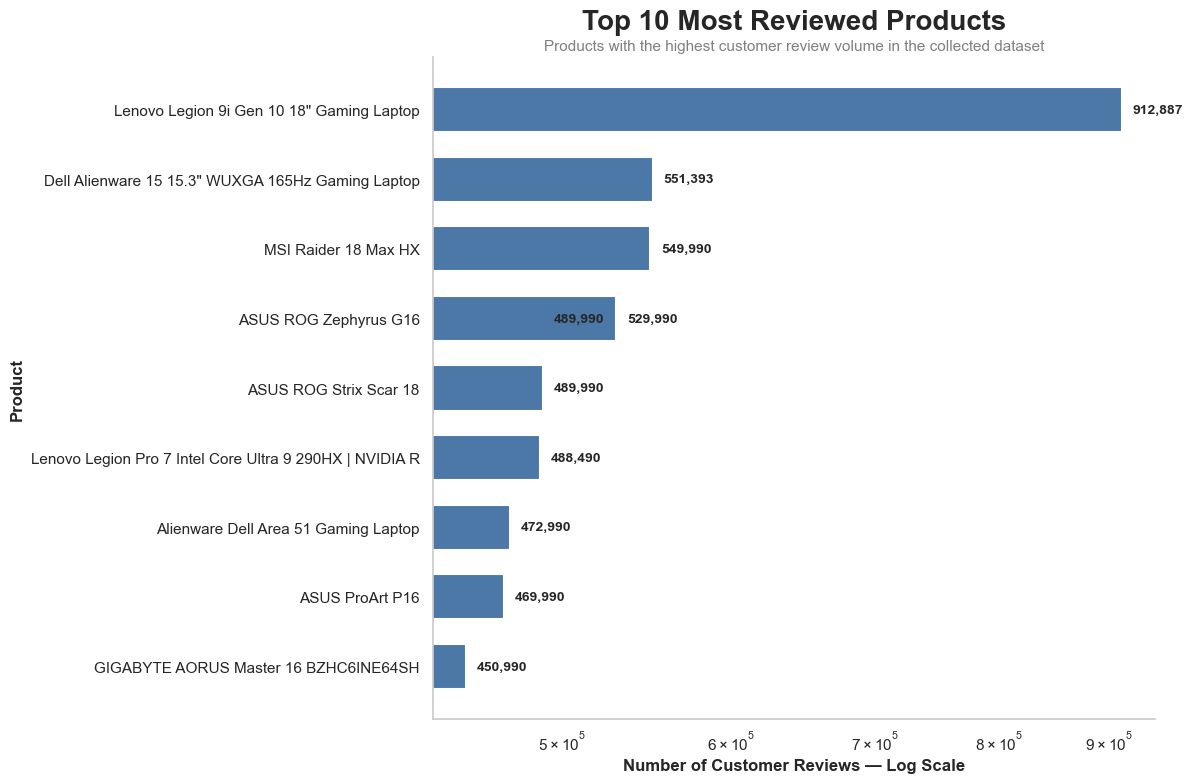

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid review counts
review_data = amazon.dropna(
    subset=["Product_Title", "Reviews_Numeric"]
).copy()

# Top 10 most reviewed products
top_products = (
    review_data
    .sort_values(
        "Reviews_Numeric",
        ascending=False
    )
    .head(10)
    .copy()
)

# Shorten long product titles for visualization
top_products["Short_Title"] = (
    top_products["Product_Title"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 55)
)

# Reverse for horizontal chart
top_products = top_products.sort_values(
    "Reviews_Numeric"
)

print("TOP 10 MOST REVIEWED PRODUCTS")
print(
    top_products[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Reviews_Numeric",
            "Rating_Numeric"
        ]
    ].to_string(index=False)
)

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))

# Category colors
palette = {
    "laptops": "#4C78A8",
    "mobiles": "#F58518",
    "washing_machines": "#54A24B"
}

colors = [
    palette.get(category, "#777777")
    for category in top_products["Category"]
]

bars = ax.barh(
    top_products["Short_Title"],
    top_products["Reviews_Numeric"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    height=0.65
)

# Log scale because review counts can vary greatly
ax.set_xscale("log")

# Value labels
for bar, value in zip(
    bars,
    top_products["Reviews_Numeric"]
):
    ax.annotate(
        f"{value:,.0f}",
        xy=(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 10 Most Reviewed Products",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Products with the highest customer review volume in the collected dataset",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Number of Customer Reviews — Log Scale",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Product",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

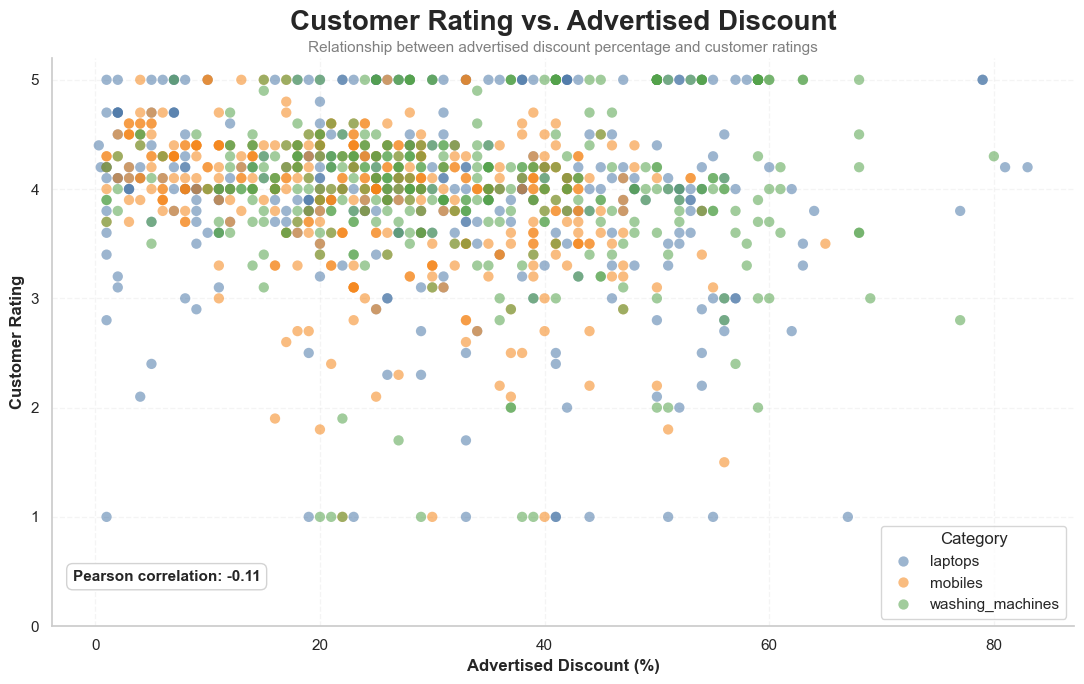

Products analyzed: 1,123
Overall Pearson correlation: -0.107


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Keep valid rating and discount values
plot_data = amazon.dropna(
    subset=["Rating_Numeric", "Discount_Pct_Final"]
).copy()

# Keep realistic ranges
plot_data = plot_data[
    (plot_data["Rating_Numeric"] >= 0) &
    (plot_data["Rating_Numeric"] <= 5) &
    (plot_data["Discount_Pct_Final"] >= 0) &
    (plot_data["Discount_Pct_Final"] <= 100)
].copy()

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

palette = {
    "laptops": "#4C78A8",
    "mobiles": "#F58518",
    "washing_machines": "#54A24B"
}

# Scatter plot
sns.scatterplot(
    data=plot_data,
    x="Discount_Pct_Final",
    y="Rating_Numeric",
    hue="Category",
    palette=palette,
    alpha=0.55,
    s=55,
    edgecolor="none",
    ax=ax
)

# Overall correlation
correlation = plot_data[
    ["Discount_Pct_Final", "Rating_Numeric"]
].corr().iloc[0, 1]

# Correlation annotation
ax.text(
    0.02,
    0.08,
    f"Pearson correlation: {correlation:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray"
    )
)

# Title
ax.set_title(
    "Customer Rating vs. Advertised Discount",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Relationship between advertised discount percentage and customer ratings",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Advertised Discount (%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Customer Rating",
    fontsize=12,
    fontweight="bold"
)

# Rating range
ax.set_ylim(0, 5.2)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.20
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Products analyzed: {len(plot_data):,}")
print(f"Overall Pearson correlation: {correlation:.3f}")

PRICE SEGMENT DISTRIBUTION (%)
Price_Segment     Budget  Mid-Range  Premium
Category                                    
laptops             4.09      20.86    75.05
mobiles            19.87      61.95    18.18
washing_machines   44.37      49.10     6.53


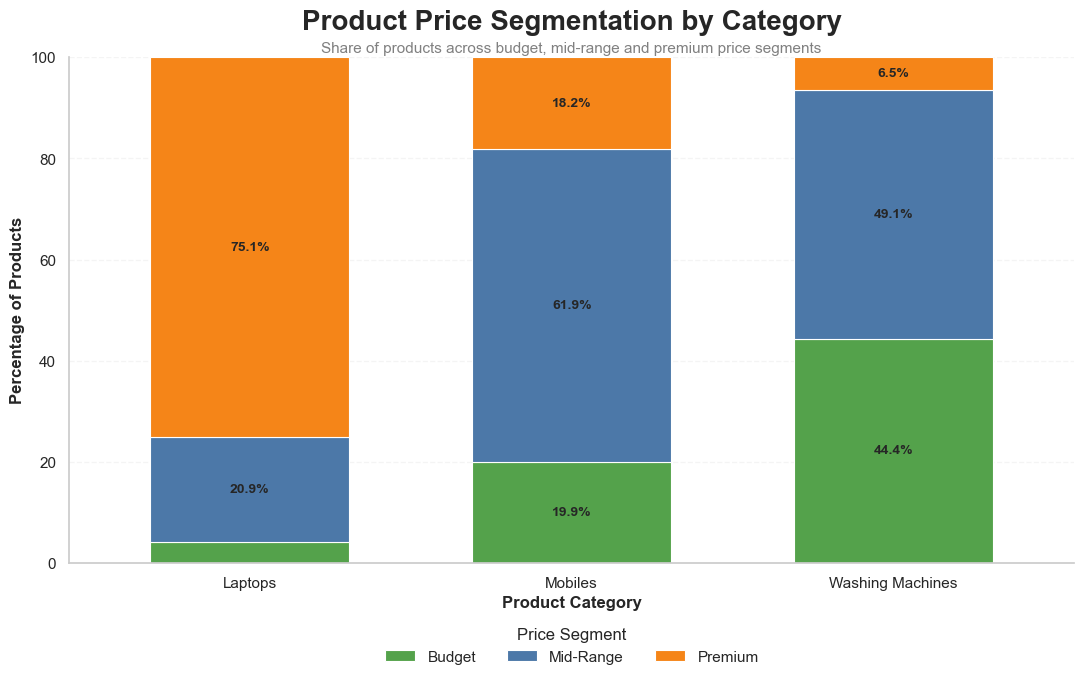

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Create price segments
def price_segment(price):
    if price < 15000:
        return "Budget"
    elif price < 50000:
        return "Mid-Range"
    else:
        return "Premium"

amazon["Price_Segment"] = amazon["Price_Numeric"].apply(price_segment)

# Category order
category_order = [
    "laptops",
    "mobiles",
    "washing_machines"
]

segment_order = [
    "Budget",
    "Mid-Range",
    "Premium"
]

# Create percentage distribution
segment_distribution = pd.crosstab(
    amazon["Category"],
    amazon["Price_Segment"],
    normalize="index"
) * 100

segment_distribution = segment_distribution.reindex(
    index=category_order,
    columns=segment_order,
    fill_value=0
)

print("PRICE SEGMENT DISTRIBUTION (%)")
print(segment_distribution.round(2))

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

# Stacked bar chart
segment_distribution.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[
        "#54A24B",
        "#4C78A8",
        "#F58518"
    ],
    width=0.62,
    edgecolor="white",
    linewidth=0.8
)

# Add percentage labels
for i, category in enumerate(segment_distribution.index):

    cumulative = 0

    for segment in segment_order:

        value = segment_distribution.loc[
            category,
            segment
        ]

        if value >= 5:

            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

        cumulative += value

# Category labels
ax.set_xticklabels(
    [
        "Laptops",
        "Mobiles",
        "Washing Machines"
    ],
    rotation=0
)

# Title
ax.set_title(
    "Product Price Segmentation by Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Share of products across budget, mid-range and premium price segments",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Percentage of Products",
    fontsize=12,
    fontweight="bold"
)

# Fixed percentage scale
ax.set_ylim(0, 100)

# Legend
ax.legend(
    title="Price Segment",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

ax.grid(
    axis="x",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

PRODUCT COUNT BY PRICE SEGMENT
Price_Segment     Budget  Mid-Range  Premium
Category                                    
laptops               19         97      349
mobiles               94        293       86
washing_machines     197        218       29


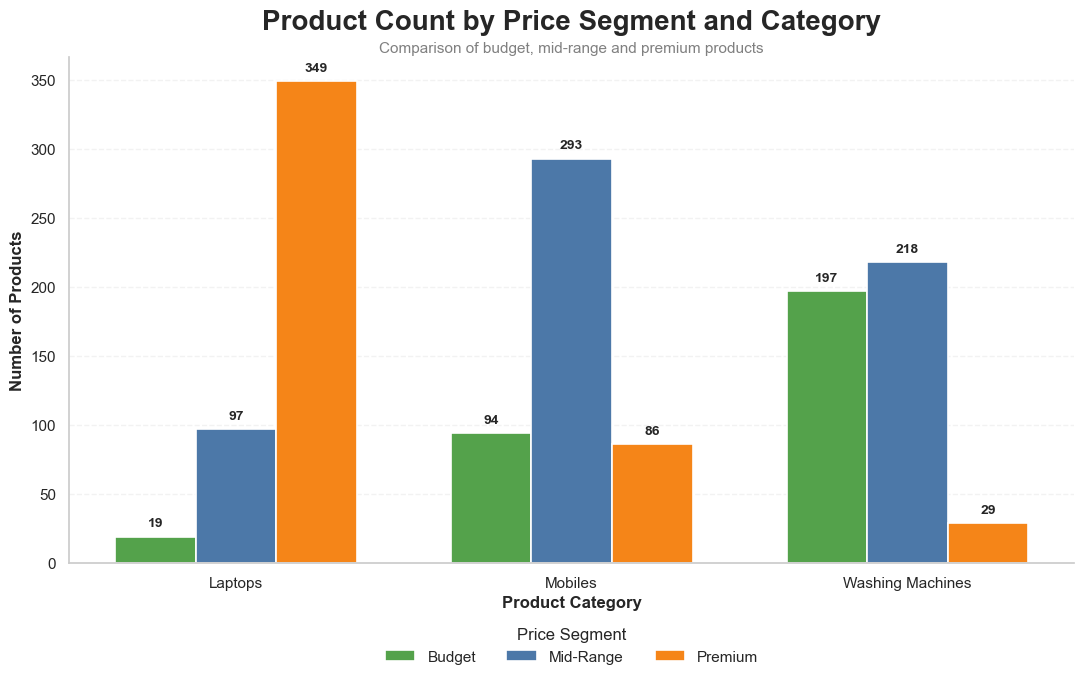

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Create price segments
amazon["Price_Segment"] = pd.cut(
    amazon["Price_Numeric"],
    bins=[-float("inf"), 15000, 50000, float("inf")],
    labels=["Budget", "Mid-Range", "Premium"]
)

# Category and segment order
category_order = [
    "laptops",
    "mobiles",
    "washing_machines"
]

segment_order = [
    "Budget",
    "Mid-Range",
    "Premium"
]

# Count products
segment_counts = pd.crosstab(
    amazon["Category"],
    amazon["Price_Segment"]
).reindex(
    index=category_order,
    columns=segment_order,
    fill_value=0
)

print("PRODUCT COUNT BY PRICE SEGMENT")
print(segment_counts)

# Professional theme
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

x = range(len(category_order))
width = 0.24

colors = {
    "Budget": "#54A24B",
    "Mid-Range": "#4C78A8",
    "Premium": "#F58518"
}

# Create grouped bars
for i, segment in enumerate(segment_order):

    values = segment_counts[segment].values

    bars = ax.bar(
        [
            pos + (i - 1) * width
            for pos in x
        ],
        values,
        width=width,
        label=segment,
        color=colors[segment],
        edgecolor="white",
        linewidth=1.2
    )

    # Value labels
    for bar, value in zip(bars, values):
        if value > 0:
            ax.annotate(
                f"{int(value)}",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height()
                ),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Laptops",
        "Mobiles",
        "Washing Machines"
    ],
    fontsize=11
)

# Title
ax.set_title(
    "Product Count by Price Segment and Category",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Comparison of budget, mid-range and premium products",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Labels
ax.set_xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

# Legend
ax.legend(
    title="Price Segment",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10)
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

CORRELATION MATRIX
                    Price_Numeric  MRP_Numeric  Discount_Pct_Final  \
Price_Numeric                1.00         0.54               -0.25   
MRP_Numeric                  0.54         1.00               -0.07   
Discount_Pct_Final          -0.25        -0.07                1.00   
Rating_Numeric               0.05        -0.04               -0.11   
Reviews_Numeric              0.51         0.29               -0.07   
RAM_GB                       0.82         0.82               -0.18   
Storage_GB                   0.75         0.72               -0.19   
Capacity_KG                  0.56         0.04                0.08   

                    Rating_Numeric  Reviews_Numeric  RAM_GB  Storage_GB  \
Price_Numeric                 0.05             0.51    0.82        0.75   
MRP_Numeric                  -0.04             0.29    0.82        0.72   
Discount_Pct_Final           -0.11            -0.07   -0.18       -0.19   
Rating_Numeric                1.00             0.0

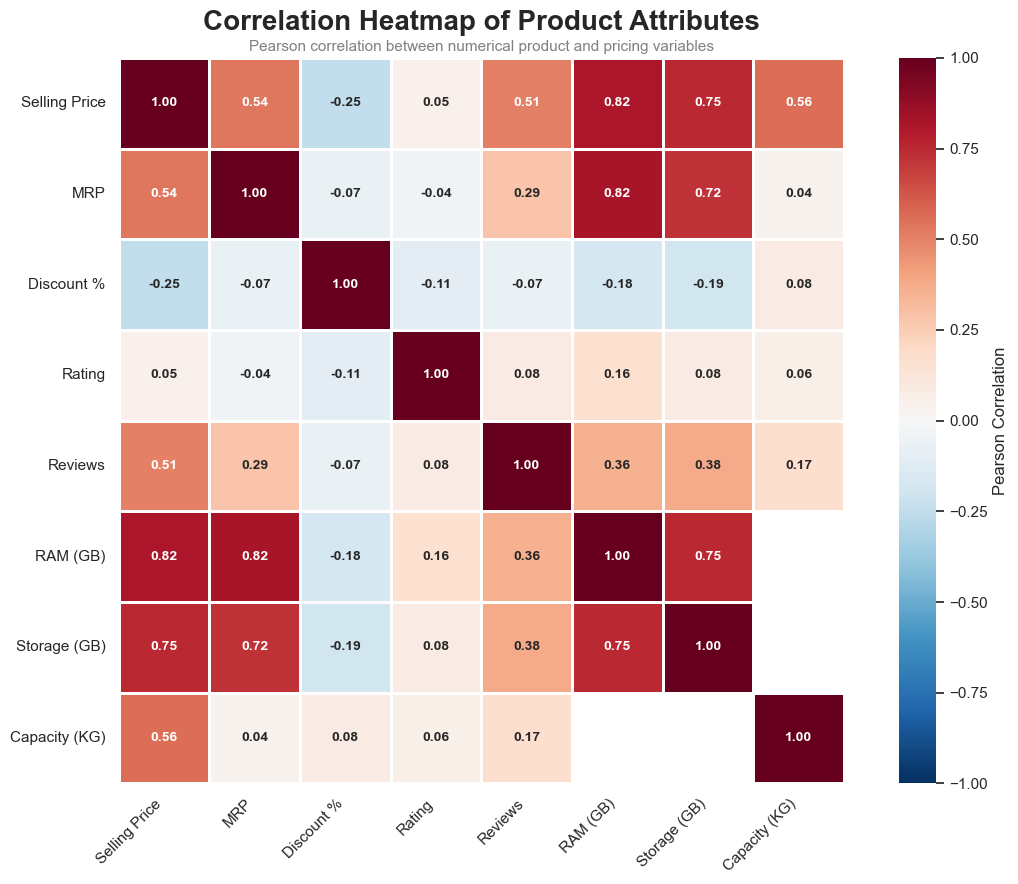

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

# Select numerical variables
numeric_columns = [
    "Price_Numeric",
    "MRP_Numeric",
    "Discount_Pct_Final",
    "Rating_Numeric",
    "Reviews_Numeric",
    "RAM_GB",
    "Storage_GB",
    "Capacity_KG"
]

# Correlation matrix
corr_matrix = amazon[numeric_columns].corr()

print("CORRELATION MATRIX")
print(corr_matrix.round(2))

# Professional theme
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(12, 9))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    linecolor="white",
    square=True,
    annot_kws={
        "size": 10,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "Pearson Correlation"
    },
    ax=ax
)

# Title
ax.set_title(
    "Correlation Heatmap of Product Attributes",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
ax.text(
    0.5,
    1.01,
    "Pearson correlation between numerical product and pricing variables",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="gray"
)

# Cleaner labels
ax.set_xticklabels(
    [
        "Selling Price",
        "MRP",
        "Discount %",
        "Rating",
        "Reviews",
        "RAM (GB)",
        "Storage (GB)",
        "Capacity (KG)"
    ],
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    [
        "Selling Price",
        "MRP",
        "Discount %",
        "Rating",
        "Reviews",
        "RAM (GB)",
        "Storage (GB)",
        "Capacity (KG)"
    ],
    rotation=0
)

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

# Load final dataset
amazon = pd.read_csv("amazon_final_analysis.csv")

print("=" * 70)
print("AMAZON PRODUCT PRICE ANALYSIS — KEY BUSINESS METRICS")
print("=" * 70)

# ---------------------------------------------------------
# 1. Dataset overview
# ---------------------------------------------------------
print("\n1. DATASET OVERVIEW")
print("-" * 50)

print("Total products:", len(amazon))
print("\nProducts by category:")
print(amazon["Category"].value_counts())

# ---------------------------------------------------------
# 2. Price metrics
# ---------------------------------------------------------
print("\n2. PRICE ANALYSIS")
print("-" * 50)

price_metrics = (
    amazon.groupby("Category")["Price_Numeric"]
    .agg(
        Average="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

print(price_metrics)

# ---------------------------------------------------------
# 3. Discount metrics
# ---------------------------------------------------------
print("\n3. DISCOUNT ANALYSIS")
print("-" * 50)

discount_metrics = (
    amazon.groupby("Category")["Discount_Pct_Final"]
    .agg(
        Average="mean",
        Median="median",
        Maximum="max"
    )
    .round(2)
)

print(discount_metrics)

# ---------------------------------------------------------
# 4. Rating metrics
# ---------------------------------------------------------
print("\n4. RATING ANALYSIS")
print("-" * 50)

rating_metrics = (
    amazon.groupby("Category")["Rating_Numeric"]
    .agg(
        Average="mean",
        Median="median"
    )
    .round(2)
)

print(rating_metrics)

# ---------------------------------------------------------
# 5. Review metrics
# ---------------------------------------------------------
print("\n5. REVIEW ANALYSIS")
print("-" * 50)

review_metrics = (
    amazon.groupby("Category")["Reviews_Numeric"]
    .agg(
        Average="mean",
        Median="median",
        Maximum="max"
    )
    .round(0)
)

print(review_metrics)

# ---------------------------------------------------------
# 6. MRP vs selling price
# ---------------------------------------------------------
print("\n6. PRICE SAVINGS")
print("-" * 50)

savings_data = amazon.dropna(
    subset=["MRP_Numeric", "Price_Numeric"]
).copy()

savings_data["Savings"] = (
    savings_data["MRP_Numeric"] -
    savings_data["Price_Numeric"]
)

savings_data = savings_data[
    savings_data["Savings"] >= 0
]

savings_metrics = (
    savings_data.groupby("Category")["Savings"]
    .agg(
        Average="mean",
        Median="median",
        Maximum="max"
    )
    .round(2)
)

print(savings_metrics)

# ---------------------------------------------------------
# 7. Top brands
# ---------------------------------------------------------
print("\n7. TOP BRANDS BY PRODUCT COUNT")
print("-" * 50)

print(
    amazon["Brand"]
    .value_counts()
    .head(10)
)

# ---------------------------------------------------------
# 8. Most reviewed products
# ---------------------------------------------------------
print("\n8. TOP 10 MOST REVIEWED PRODUCTS")
print("-" * 50)

top_reviewed = (
    amazon
    .sort_values(
        "Reviews_Numeric",
        ascending=False
    )
    .head(10)
)

print(
    top_reviewed[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Reviews_Numeric",
            "Rating_Numeric",
            "Price_Numeric"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("METRIC EXTRACTION COMPLETE")
print("=" * 70)

AMAZON PRODUCT PRICE ANALYSIS — KEY BUSINESS METRICS

1. DATASET OVERVIEW
--------------------------------------------------
Total products: 1382

Products by category:
Category
mobiles             473
laptops             465
washing_machines    444
Name: count, dtype: int64

2. PRICE ANALYSIS
--------------------------------------------------
                    Average   Median  Minimum   Maximum
Category                                               
laptops           129344.41  77990.0    79.18  999990.0
mobiles            35725.86  24989.0   899.00  262998.0
washing_machines   21194.11  17355.0   189.00  159890.0

3. DISCOUNT ANALYSIS
--------------------------------------------------
                  Average  Median  Maximum
Category                                  
laptops             31.96    32.0     83.0
mobiles             25.05    25.0     65.0
washing_machines    33.23    31.0     80.0

4. RATING ANALYSIS
--------------------------------------------------
               

In [52]:
import pandas as pd

amazon = pd.read_csv("amazon_final_analysis.csv")

# Find suspicious review values
suspicious = amazon[
    (amazon["Reviews_Numeric"] > 100000) |
    (
        (amazon["Price_Numeric"].notna()) &
        (
            abs(
                amazon["Reviews_Numeric"] -
                amazon["Price_Numeric"]
            ) <= 5
        )
    )
].copy()

print("=" * 70)
print("REVIEW COUNT DATA QUALITY CHECK")
print("=" * 70)

print("\nTotal products:", len(amazon))
print("Suspicious review records:", len(suspicious))

print("\nSuspicious records:")
print(
    suspicious[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric",
            "Reviews_Numeric",
            "Rating_Numeric"
        ]
    ].sort_values(
        "Reviews_Numeric",
        ascending=False
    ).to_string(index=False)
)

print("\nReview statistics:")
print(
    amazon["Reviews_Numeric"]
    .describe()
    .round(2)
)

print("\nPercentiles:")
print(
    amazon["Reviews_Numeric"]
    .quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
    .round(2)
)

REVIEW COUNT DATA QUALITY CHECK

Total products: 1382
Suspicious review records: 183

Suspicious records:
        Category          Brand                                                                                                                                                                                      Product_Title  Price_Numeric  Reviews_Numeric  Rating_Numeric
         laptops         Lenovo                                                                                                                                                          Lenovo Legion 9i Gen 10 18" Gaming Laptop      912887.00         912887.0             NaN
         laptops           Dell                                                                                                                                                  Dell Alienware 15 15.3" WUXGA 165Hz Gaming Laptop      551393.22         551393.0             NaN
         laptops            MSI                                      

In [53]:
import pandas as pd
import numpy as np

amazon = pd.read_csv("amazon_final_analysis.csv")

# Calculate discount independently from Price and MRP
amazon["Calculated_Discount"] = np.where(
    (amazon["MRP_Numeric"] > 0) &
    (amazon["Price_Numeric"] >= 0),
    ((amazon["MRP_Numeric"] - amazon["Price_Numeric"]) /
     amazon["MRP_Numeric"]) * 100,
    np.nan
)

# Find suspicious MRP relationships
suspicious_mrp = amazon[
    amazon["MRP_Numeric"].notna() &
    amazon["Price_Numeric"].notna() &
    (
        (amazon["MRP_Numeric"] < amazon["Price_Numeric"]) |
        (amazon["Calculated_Discount"] < 0) |
        (amazon["Calculated_Discount"] > 90)
    )
].copy()

print("=" * 70)
print("MRP / DISCOUNT DATA QUALITY CHECK")
print("=" * 70)

print("\nTotal products:", len(amazon))
print("Suspicious MRP records:", len(suspicious_mrp))

print("\nSuspicious records:")
print(
    suspicious_mrp[
        [
            "Category",
            "Brand",
            "Product_Title",
            "Price_Numeric",
            "MRP_Numeric",
            "Discount_Pct_Final",
            "Calculated_Discount"
        ]
    ]
    .sort_values("Calculated_Discount", ascending=False)
    .head(100)
    .to_string(index=False)
)

print("\nCalculated discount statistics:")
print(
    amazon["Calculated_Discount"]
    .describe()
    .round(2)
)

print("\nDiscount percentiles:")
print(
    amazon["Calculated_Discount"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

MRP / DISCOUNT DATA QUALITY CHECK

Total products: 1382
Suspicious MRP records: 12

Suspicious records:
        Category       Brand                                                                                                                           Product_Title  Price_Numeric  MRP_Numeric  Discount_Pct_Final  Calculated_Discount
washing_machines   Whirlpool                                                                      Whirlpool 7 kg Inverter Fully Automatic Front Load Washing Machine        25490.0    2549000.0                38.0                 99.0
washing_machines       Bosch                                                       Bosch 8 Kg 5 Star Fully Automatic Front Load Washing Machine with In-built Heater        38290.0    3829000.0                32.0                 99.0
washing_machines         DMR                                                                                                                   DMR Model DMR 46-1218         7099.0     709900.0  

In [54]:
import pandas as pd
import numpy as np

amazon = pd.read_csv("amazon_final_analysis.csv")

# ---------------------------------------------------------
# 1. Calculate discount directly from Price and MRP
# ---------------------------------------------------------

amazon["Calculated_Discount"] = np.where(
    (amazon["MRP_Numeric"] > 0) &
    (amazon["Price_Numeric"] >= 0),
    ((amazon["MRP_Numeric"] - amazon["Price_Numeric"]) /
     amazon["MRP_Numeric"]) * 100,
    np.nan
)

# ---------------------------------------------------------
# 2. Identify corrupted MRP values
#    Main pattern found: MRP approximately 100x Price
# ---------------------------------------------------------

corrupt_mrp = (
    amazon["Price_Numeric"].notna() &
    amazon["MRP_Numeric"].notna() &
    (amazon["MRP_Numeric"] >= amazon["Price_Numeric"] * 50)
)

print("Corrupted MRP records found:", corrupt_mrp.sum())

# ---------------------------------------------------------
# 3. Repair corrupted MRP using advertised discount
# ---------------------------------------------------------

repairable = (
    corrupt_mrp &
    amazon["Discount_Pct_Final"].notna() &
    (amazon["Discount_Pct_Final"] > 0) &
    (amazon["Discount_Pct_Final"] < 100)
)

amazon.loc[repairable, "MRP_Numeric"] = (
    amazon.loc[repairable, "Price_Numeric"] /
    (1 - amazon.loc[repairable, "Discount_Pct_Final"] / 100)
)

# ---------------------------------------------------------
# 4. Recalculate discount after MRP correction
# ---------------------------------------------------------

amazon["Calculated_Discount"] = np.where(
    (amazon["MRP_Numeric"] > 0) &
    (amazon["Price_Numeric"] >= 0),
    ((amazon["MRP_Numeric"] - amazon["Price_Numeric"]) /
     amazon["MRP_Numeric"]) * 100,
    np.nan
)

# Use calculated discount as the final analytical discount
amazon["Discount_Pct_Final"] = amazon["Calculated_Discount"]

# ---------------------------------------------------------
# 5. Remove temporary calculation column
# ---------------------------------------------------------

amazon.drop(columns=["Calculated_Discount"], inplace=True)

# ---------------------------------------------------------
# 6. Save corrected dataset
# ---------------------------------------------------------

amazon.to_csv("amazon_final_analysis_corrected.csv", index=False)

# ---------------------------------------------------------
# 7. Validation
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("CORRECTED DATASET")
print("=" * 70)

print("\nShape:", amazon.shape)

print("\nCategory counts:")
print(amazon["Category"].value_counts())

print("\nDuplicate ASINs:",
      amazon["ASIN"].duplicated().sum())

print("\nMissing values:")
print(
    amazon.isna().sum()
)

print("\nPrice / MRP / Discount statistics:")

print(
    amazon[
        [
            "Price_Numeric",
            "MRP_Numeric",
            "Discount_Pct_Final"
        ]
    ].describe().round(2)
)

print("\nMaximum discount:")
print(
    amazon["Discount_Pct_Final"].max()
)

print("\nProducts with MRP < Price:")
print(
    (
        amazon["MRP_Numeric"] <
        amazon["Price_Numeric"]
    ).sum()
)

Corrupted MRP records found: 12

CORRECTED DATASET

Shape: (1382, 13)

Category counts:
Category
mobiles             473
laptops             465
washing_machines    444
Name: count, dtype: int64

Duplicate ASINs: 0

Missing values:
ASIN                     0
Category                 0
Brand                    0
Product_Title            0
Price_Numeric            0
MRP_Numeric             81
Discount_Pct_Final      81
Rating_Numeric         183
Reviews_Numeric          0
RAM_GB                 713
Storage_GB             735
Storage_Type           969
Capacity_KG           1014
dtype: int64

Price / MRP / Discount statistics:
       Price_Numeric  MRP_Numeric  Discount_Pct_Final
count        1382.00      1301.00             1301.00
mean        62556.92     84565.40               28.00
std         99430.01    122934.95               16.57
min            79.18       249.00                0.00
25%         16340.75     22990.00               16.50
50%         33194.50     47990.00           

In [55]:
import pandas as pd
import numpy as np

amazon = pd.read_csv("amazon_final_analysis_corrected.csv")

print("=" * 70)
print("RATING DATA QUALITY CHECK")
print("=" * 70)

print("\nTotal products:", len(amazon))

print("\nMissing ratings:", amazon["Rating_Numeric"].isna().sum())

print("\nRating statistics:")
print(
    amazon["Rating_Numeric"]
    .describe()
    .round(2)
)

print("\nUnique rating values:")
print(
    sorted(
        amazon["Rating_Numeric"]
        .dropna()
        .unique()
    )
)

# Invalid ratings
invalid = amazon[
    amazon["Rating_Numeric"].notna() &
    (
        (amazon["Rating_Numeric"] < 0) |
        (amazon["Rating_Numeric"] > 5)
    )
].copy()

print("\nInvalid ratings:", len(invalid))

if len(invalid) > 0:
    print("\nInvalid records:")
    print(
        invalid[
            [
                "Category",
                "Brand",
                "Product_Title",
                "Price_Numeric",
                "Rating_Numeric"
            ]
        ].to_string(index=False)
    )

print("\nRating counts by category:")
print(
    amazon.groupby("Category")["Rating_Numeric"]
    .agg(
        Count="count",
        Missing="size"
    )
)

print("\nAverage rating by category:")
print(
    amazon.groupby("Category")["Rating_Numeric"]
    .mean()
    .round(2)
)

RATING DATA QUALITY CHECK

Total products: 1382

Missing ratings: 183

Rating statistics:
count    1199.00
mean        3.97
std         0.71
min         1.00
25%         3.70
50%         4.00
75%         4.30
max         5.00
Name: Rating_Numeric, dtype: float64

Unique rating values:
[1.0, 1.5, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]

Invalid ratings: 0

Rating counts by category:
                  Count  Missing
Category                        
laptops             339      465
mobiles             458      473
washing_machines    402      444

Average rating by category:
Category
laptops             3.92
mobiles             3.93
washing_machines    4.05
Name: Rating_Numeric, dtype: float64
